In [4]:
# List of libraries to check and install if necessary
required_libraries = [
    'pandas', 'numpy', 'statistics', 'matplotlib', 'seaborn',
    'scikit-learn', 'imbalanced-learn', 'joblib', 'lightgbm'
]

# Function to check if a library is installed
def is_library_installed(library_name):
    try:
        __import__(library_name)
        return True
    except ImportError:
        return False

# Check and install missing libraries
for library in required_libraries:
    if not is_library_installed(library):
        print(f"Installing {library}...")
        !pip install {library}
        print(f"{library} has been successfully installed!")

Installing scikit-learn...
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 23.1.2 -> 23.2.1
[notice] To update, run: python3.9 -m pip install --upgrade pip
scikit-learn has been successfully installed!
Installing imbalanced-learn...
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/iss

In [5]:
# Import libraries 
# Pandas to work with structured data on the form of dataframes 
# Numpy is a powerful library for numerical and array operations 

import pandas as pd
import numpy as np

# statistics module, which is a built-in Python module for performing statistical operations on data. 
# this module used to calculate various statistical measures such as mean, median, standard deviation, variance. 
import statistics

# matplot used for creating various types of plots and charts.
import matplotlib.pyplot as plt

# Seaborn is a data visualization libraryfor creating informative and attractive statistical graphics
import seaborn as sns

# functions for splitting datasets into training and testing sets,and cross-validation.
from sklearn.model_selection import train_test_split

# The StandardScaler is used for standardizing features.
from sklearn.preprocessing import StandardScaler

# Various metrics for evaluating the performance of machine learning models
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

# Implementations of the Naive Bayes classification algorithm
from sklearn.naive_bayes import GaussianNB

# Various linear and logistic regression implementations. 
from sklearn.linear_model import LogisticRegression

# Import decision tree algorithms
from sklearn.tree import DecisionTreeClassifier

# Classes are used for hyperparameter tuning using grid search and randomized search
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

# Includes k-nearest neighbors (KNN) algorithms.
from sklearn.neighbors import KNeighborsClassifier

# Ensemble learning methods
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# SciPy is a library for mathematics, science, and engineering. 
# The randint function from SciPy to generate random integers
from scipy.stats import randint as sp_randint

# Testing and experimenting with machine learning algorithms.
from sklearn.datasets import make_classification

# Allows you to select the top K best features based on a specified scoring function
from sklearn.feature_selection import SelectKBest

# Computes the F-value for each feature,
# Indicating how well it discriminates between classes in a classification problem.
from sklearn.feature_selection import f_classif

# Scoring function for feature selection, this one is specifically for categorical features.
# It computes the chi-squared statistic to assess the independence between each feature and the target variable.
from sklearn.feature_selection import chi2

# SMOTE used to oversample the training data and balance the class distribution
from imblearn.over_sampling import SMOTE

# To save machine learning models and use it in the application 
import joblib

# a gradient boosting framework used for classification and regression tasks.
import lightgbm as lgb 


In [6]:
#  Load a dataset into a Pandas DataFrame for data analysis and machine learning tasks
dataset = pd.read_csv('CHD_preprocessed.csv') 

In [7]:
# Make a copy of the dataset
db = dataset.copy()

In [8]:
# Display all columns and rows in a pandas DataFrame without truncation 
# To prevent overwhelming output in large DataFrames
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [9]:
# summary of the DataFrame structure and contents.
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4133 entries, 0 to 4132
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4133 non-null   int64  
 1   age              4133 non-null   int64  
 2   education        4133 non-null   int64  
 3   currentSmoker    4133 non-null   int64  
 4   cigsPerDay       4133 non-null   float64
 5   BPMeds           4133 non-null   float64
 6   prevalentStroke  4133 non-null   int64  
 7   prevalentHyp     4133 non-null   int64  
 8   diabetes         4133 non-null   int64  
 9   totChol          4133 non-null   float64
 10  sysBP            4133 non-null   float64
 11  diaBP            4133 non-null   float64
 12  BMI              4133 non-null   float64
 13  heartRate        4133 non-null   float64
 14  glucose          4133 non-null   float64
 15  TenYearCHD       4133 non-null   int64  
dtypes: float64(8), int64(8)
memory usage: 516.8 KB


In [10]:
#  The count of missing values for each column in the DataFrame
missing_values_count = db.isnull().sum() 
missing_values_count

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [11]:
#  filters rows in the DataFrame  where the 'currentSmoker' column has a value of 1 (indicating smokers) 
# returns the indices (row labels) of those rows

smokers = db[db['currentSmoker'] == 1].index
smokers

Index([   2,    3,    4,    7,    9,   12,   14,   15,   16,   17,
       ...
       4111, 4119, 4120, 4122, 4124, 4125, 4128, 4129, 4130, 4131],
      dtype='int64', length=2045)

In [12]:
# Extract the number of cigarettes smoked per day by individuals who are classified as smokers based on the 'currentSmoker' column
cigarettes_by_smokers = []

# Iterate over the indices of smokers
for i in smokers:
    # Check if the 'cigsPerDay' value is not missing (not NaN)
    if pd.notna(db['cigsPerDay'][i]):
        cigarettes_by_smokers.append(db['cigsPerDay'][i])

# The number of cigarettes smoked per day by individuals classified as smokers

len(cigarettes_by_smokers)


2045

In [13]:
# The median of the number of cigarettes smoked per day by smokers using the statistics module
smoker_median = statistics.median(cigarettes_by_smokers)
smoker_median

20.0

# A summary of the data definition:

## Demographic:

**Sex:** Nominal categorical variable with values "male" or "female."

**Age:** Continuous variable representing the age of the patient. Although recorded ages are truncated to whole numbers, age is conceptually continuous.
Behavioral:

**Current Smoker:** Nominal categorical variable indicating whether the patient is a current smoker.

**Cigs Per Day:** Continuous variable representing the number of cigarettes smoked on average in one day. It can be considered continuous even though the recorded values are discrete.

## Medical(History)

**BP Meds:** Nominal categorical variable indicating whether the patient was on blood pressure medication.

**Prevalent Stroke:** Nominal categorical variable indicating whether the patient had previously had a stroke.

**Prevalent Hyp:** Nominal categorical variable indicating whether the patient was hypertensive.

**Diabetes:** Nominal categorical variable indicating whether the patient had diabetes.

## Medical(Current)

**Tot Chol:** Continuous variable representing the total cholesterol level.

**Sys BP:** Continuous variable representing systolic blood pressure.

**Dia BP:** Continuous variable representing diastolic blood pressure.

**BMI:** Continuous variable representing Body Mass Index.

**Heart Rate:** Continuous variable representing the heart rate. Although discrete in nature, it's considered continuous due to a large number of possible values.

**Glucose:** Continuous variable representing the glucose level.

## Predict variable (desired target)

**Ten years risk of coronary heart disease CHD:** Binary variable where "1" means "Yes" (indicating the presence of coronary heart disease risk) and "0" means "No" (indicating the absence of coronary heart disease risk).

In [14]:
db.columns = ['Sex','Age','Education','CurrentSmoker','CigsPerDay','BPMeds','PrevalentStroke','PrevalentHyp','Diabetes','TotChol','SysBP','DiaBP','BMI','HeartRate','Glucose','TenYearCHD']
# Display the first 5 rows of a DataFrame 
db.head()

,Sex,Age,Education,CurrentSmoker,CigsPerDay,BPMeds,PrevalentStroke,PrevalentHyp,Diabetes,TotChol,SysBP,DiaBP,BMI,HeartRate,Glucose,TenYearCHD
0,1,39,1,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [15]:
# drop method to remove a column named 'Education' from the DataFrame 
db = db.drop(columns=['Education'])

In [16]:
db.shape

(4133, 15)

In [17]:
# summary of the DataFrame
db.describe()

,Sex,Age,CurrentSmoker,CigsPerDay,BPMeds,PrevalentStroke,PrevalentHyp,Diabetes,TotChol,SysBP,DiaBP,BMI,HeartRate,Glucose,TenYearCHD
count,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000,4133.000000
mean,0.427293,49.557222,0.494798,9.101621,0.034358,0.006049,0.311154,0.025647,236.664408,132.367046,82.872248,25.778571,75.925236,81.946528,0.151948
std,0.494745,8.561628,0.500033,11.918440,0.182168,0.077548,0.463022,0.158100,43.909188,22.080332,11.952654,4.074360,12.049188,22.860954,0.359014
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.060000,68.000000,72.000000,0.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,80.000000,0.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,262.000000,144.000000,89.500000,27.990000,83.000000,85.000000,0.000000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


# The Correlation


In [18]:
# Each cell contains the correlation coefficient(Pearson correlation by default) between two columns in the dataset.
corr = db.corr()
corr

,Sex,Age,CurrentSmoker,CigsPerDay,BPMeds,PrevalentStroke,PrevalentHyp,Diabetes,TotChol,SysBP,DiaBP,BMI,HeartRate,Glucose,TenYearCHD
Sex,1.000000,-0.029085,0.199750,0.320773,-0.055519,-0.004304,0.003700,0.017658,-0.073074,-0.036736,0.055970,0.079708,-0.116473,0.005829,0.084014
Age,-0.029085,1.000000,-0.212415,-0.192079,0.142893,0.058712,0.309546,0.101186,0.266915,0.394675,0.209126,0.135138,-0.008788,0.116543,0.228260
CurrentSmoker,0.199750,-0.212415,1.000000,0.771739,-0.056488,-0.033515,-0.105899,-0.041171,-0.046711,-0.130008,-0.108591,-0.161724,0.057717,-0.053704,0.016537
CigsPerDay,0.320773,-0.192079,0.771739,1.000000,-0.050877,-0.033658,-0.069803,-0.035805,-0.024522,-0.089390,-0.055252,-0.088904,0.072660,-0.054101,0.052555
BPMeds,-0.055519,0.142893,-0.056488,-0.050877,1.000000,0.122337,0.272050,0.045024,0.082952,0.271920,0.205084,0.101962,0.019473,0.050767,0.094079
PrevalentStroke,-0.004304,0.058712,-0.033515,-0.033658,0.122337,1.000000,0.075632,0.007083,0.000170,0.057571,0.045743,0.025547,-0.018164,0.018339,0.062599
PrevalentHyp,0.003700,0.309546,-0.105899,-0.069803,0.272050,0.075632,1.000000,0.076097,0.164719,0.697432,0.617669,0.300584,0.151269,0.084041,0.179941
Diabetes,0.017658,0.101186,-0.041171,-0.035805,0.045024,0.007083,0.076097,1.000000,0.040669,0.109821,0.049376,0.082396,0.046361,0.604357,0.097614
TotChol,-0.073074,0.266915,-0.046711,-0.024522,0.082952,0.000170,0.164719,0.040669,1.000000,0.210655,0.168231,0.115800,0.089570,0.047502,0.083328
SysBP,-0.036736,0.394675,-0.130008,-0.089390,0.271920,0.057571,0.697432,0.109821,0.210655,1.000000,0.784691,0.324970,0.186476,0.136629,0.218715


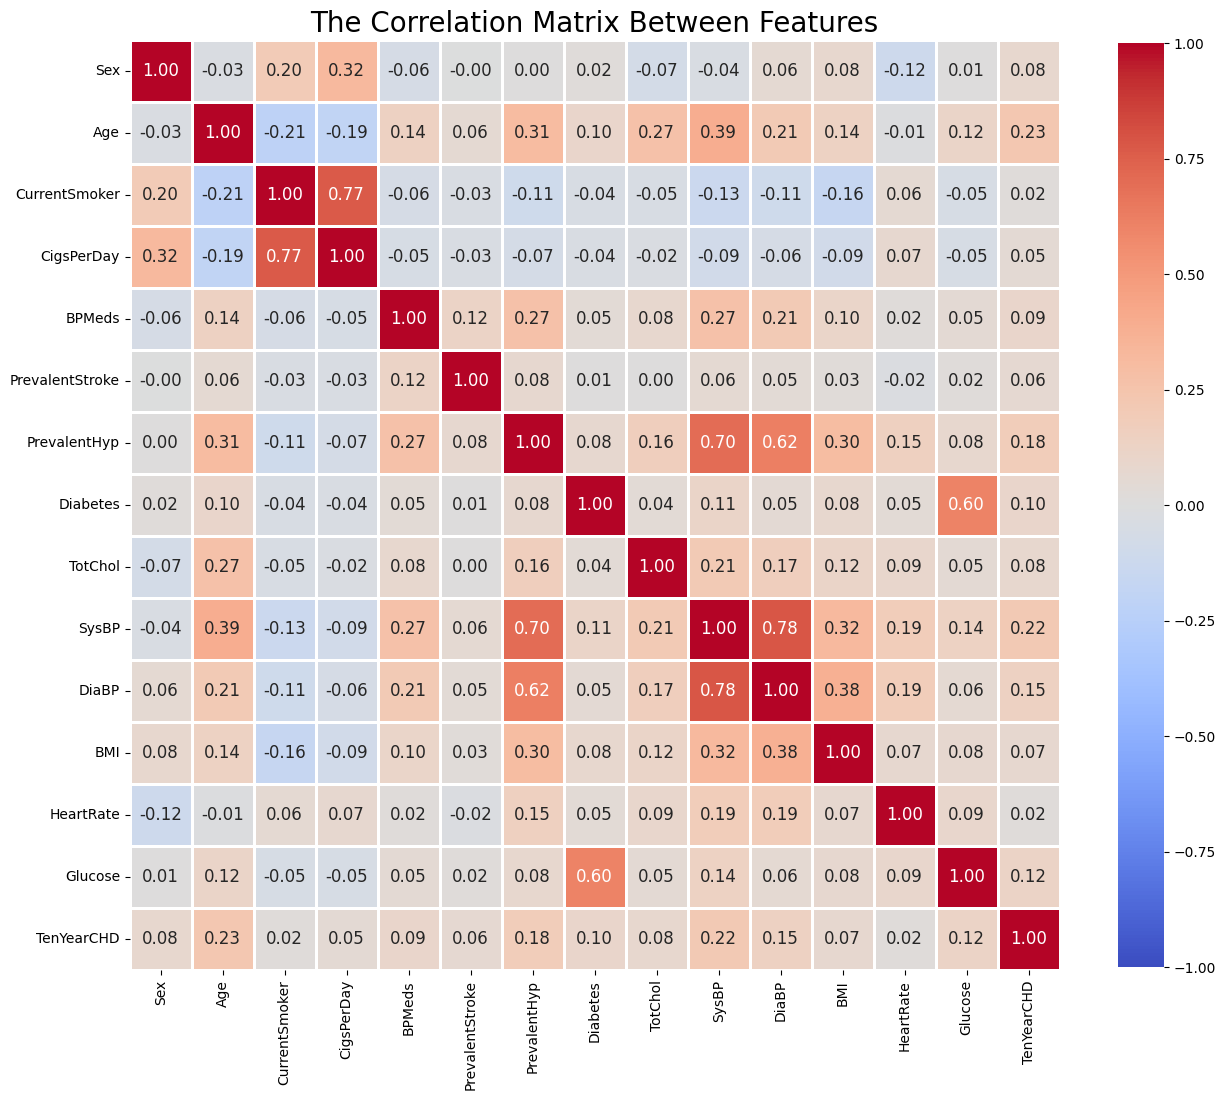

In [19]:
# a heatmap of the correlation matrix to visually represent the strength and direction of correlations between variables.
plt.figure(figsize=(15,20))
# Create the heatmap with custom settings
sns.heatmap(db.corr(),fmt=".2f", cbar=True ,cmap='coolwarm', annot_kws={"fontsize": 12}, center=0, square=True,vmin=-1,vmax=1, linewidths=.9,annot=True, cbar_kws={"shrink": .6})
# Add a title
plt.title("The Correlation Matrix Between Features", fontsize=20)
plt.show()


# Data Analysis

/var/folders/nk/4d0cx0sn18x5xyc2dhmv1_240000gn/T/ipykernel_61456/2946623042.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  countplot.set_xticklabels(countplot.get_xticklabels(), fontsize=20)
/var/folders/nk/4d0cx0sn18x5xyc2dhmv1_240000gn/T/ipykernel_61456/2946623042.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  countplot.set_xticklabels(countplot.get_xticklabels(), fontsize=20)
/var/folders/nk/4d0cx0sn18x5xyc2dhmv1_240000gn/T/ipykernel_61456/2946623042.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  countplot.set_xticklabels(countplot.get_xticklabels(), fontsize=20)
/var/folders/nk/4d0cx0sn18x5xyc2dhmv1_240000gn/T/ipykernel_61456/2946623042.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  countplot.set_xticklabels(countplot.get_xticklabels(), fontsize=20)
/var/folders/nk/4d0cx0sn18x5xyc2dhmv1_240000gn/T/ipykernel_61456/2946623042.py:16: UserW

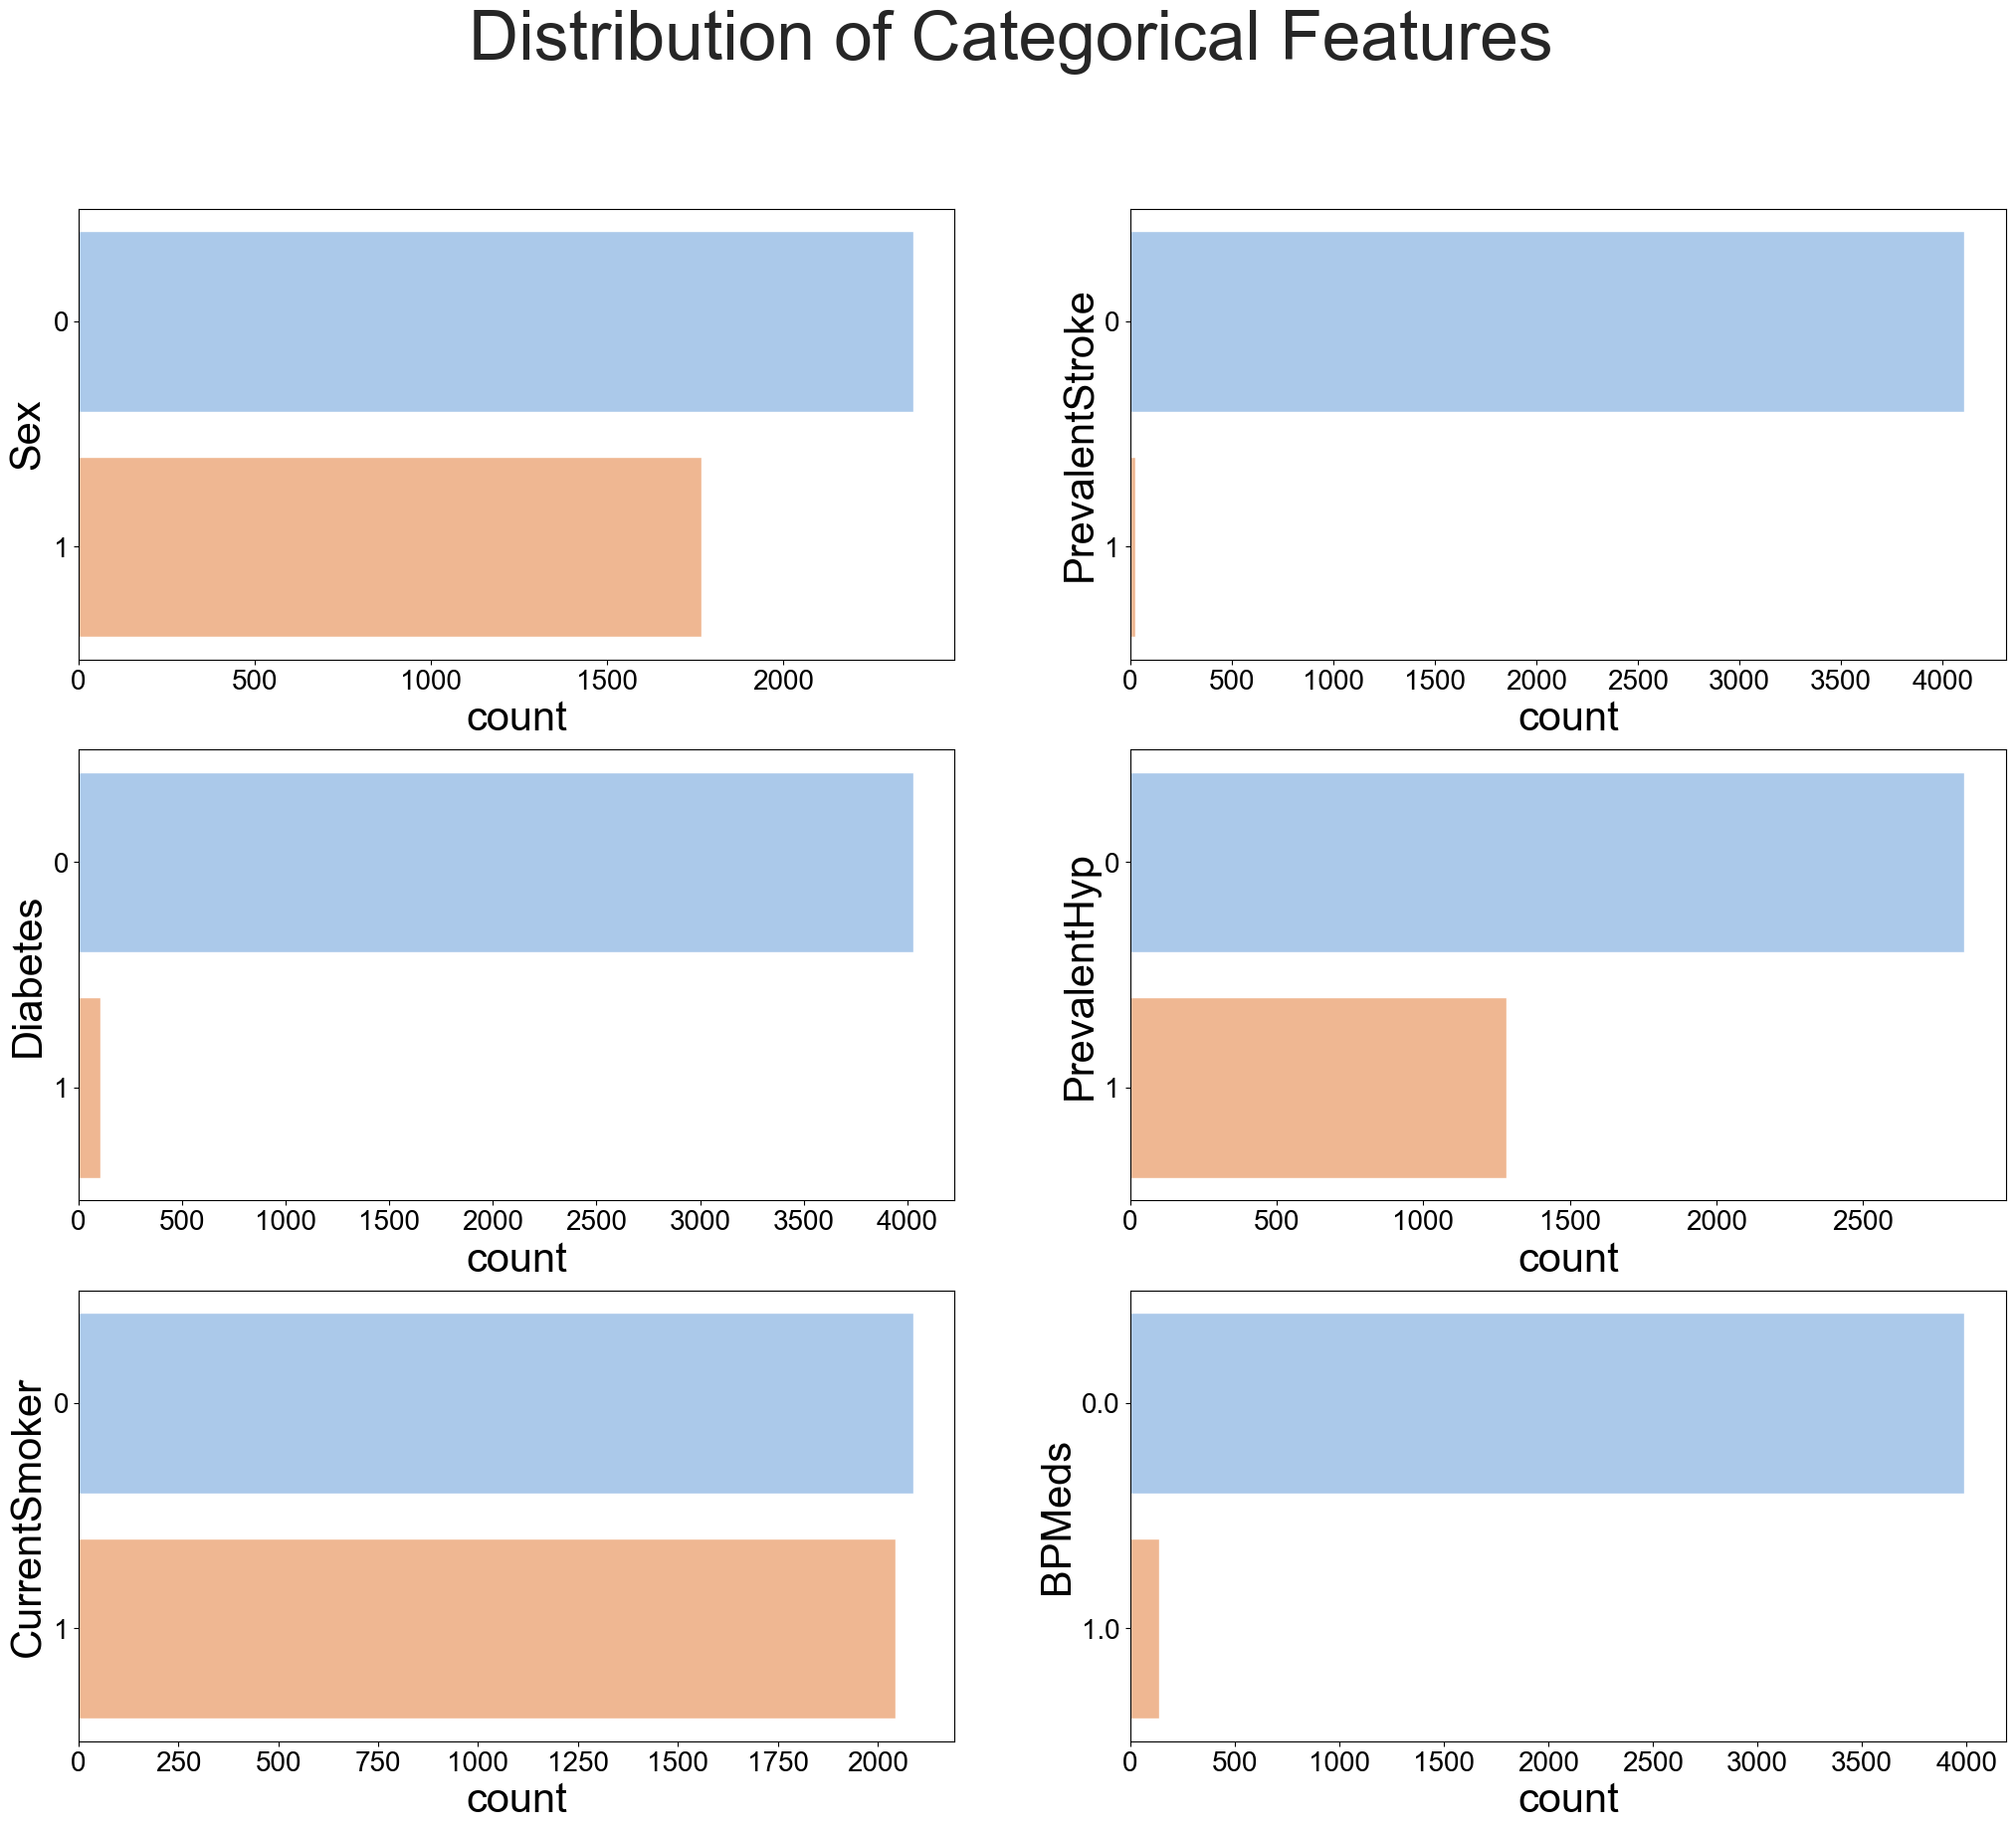

In [20]:
# Creating a grid of count plots for the categorical features in the dataset.
categorical_features = ['Sex', 'PrevalentStroke','Diabetes', 'PrevalentHyp', 'CurrentSmoker', 'BPMeds']

# Create a grid of subplots (3 rows, 2 columns) with a specified figure size
fig, ax = plt.subplots(3, 2, figsize=(25, 20))


custom_palette = sns.color_palette("pastel")  # You can choose different palettes
sns.set(style="whitegrid") 

# Loop through each categorical feature and create a count plot
for variable, subplot in zip(categorical_features, ax.flatten()):
    countplot = sns.countplot(y=db[variable], ax=subplot, palette=custom_palette )
    countplot.set_ylabel(variable, fontsize = 30)
    countplot.set_xlabel(countplot.get_xlabel(), fontsize=30)
    countplot.set_xticklabels(countplot.get_xticklabels(), fontsize=20)
    countplot.set_yticklabels(countplot.get_yticklabels(), fontsize=20)

    
# Add a title to the entire grid of subplots
title = "Distribution of Categorical Features"
plt.suptitle(title, fontsize=50)

# Adjust layout for better spacing between subplots
#plt.tight_layout()   

# Show the plot
plt.show()

# Numerical Features analysis




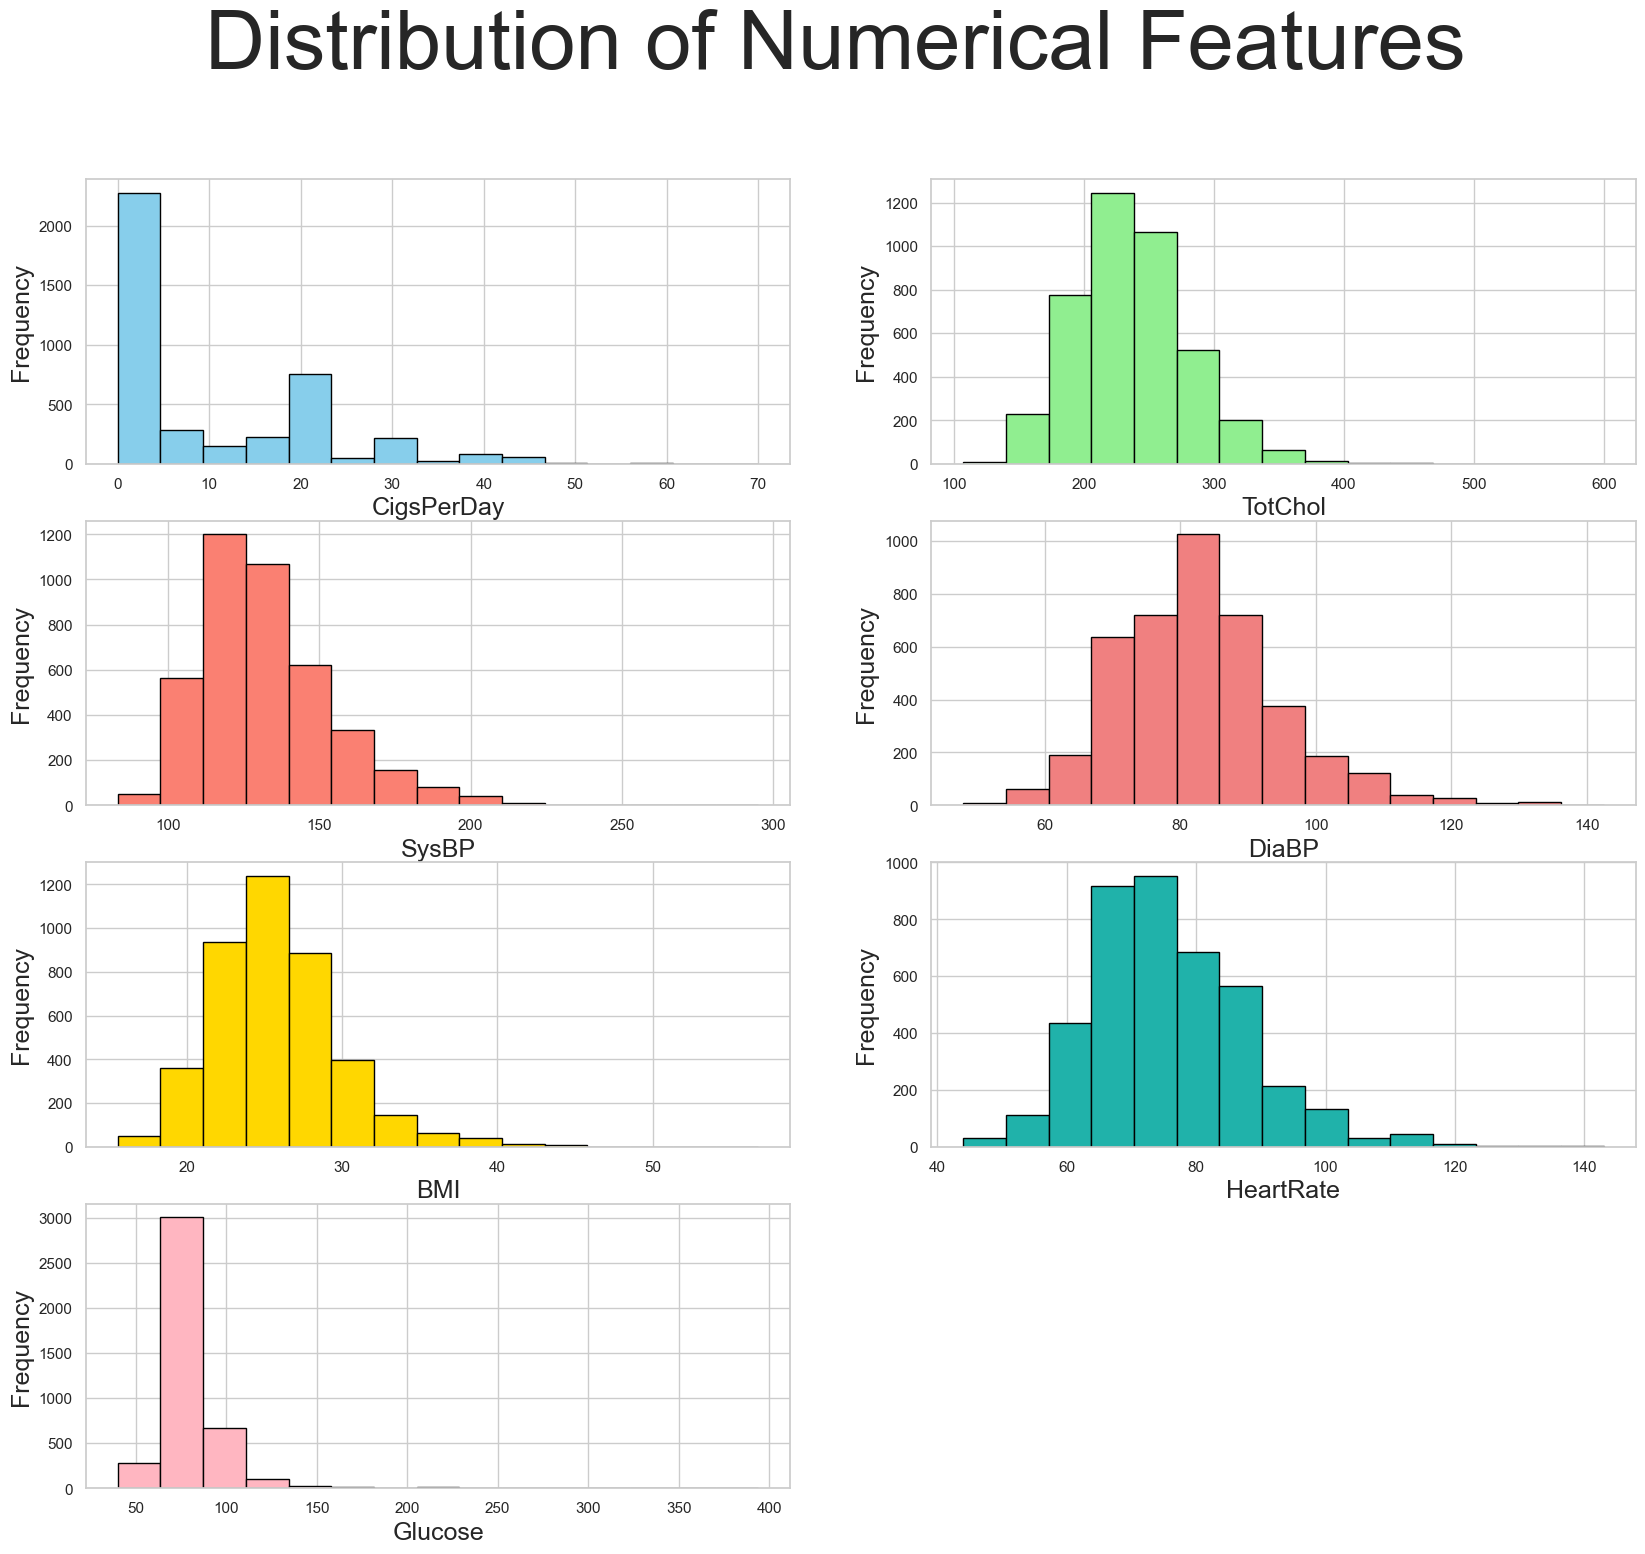

In [21]:
# Define the numerical features
numeric_features = ['CigsPerDay', 'TotChol', 'SysBP', 'DiaBP', 'BMI', 'HeartRate', 'Glucose']

# Create a figure with subplots
fig = plt.figure(figsize=(20, 17))

# Define custom colors and styles
custom_colors = ['skyblue', 'lightgreen', 'salmon', 'lightcoral', 'gold', 'lightseagreen', 'lightpink']
custom_titles = ['CigsPerDay Distribution', 'Total Cholesterol Distribution', 'Systolic BP Distribution', 'Diastolic BP Distribution', 'BMI Distribution', 'Heart Rate Distribution', 'Glucose Distribution']

# Create histograms for each numerical feature
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(4, 2, i)  # 2 rows, 3 columns
    plt.hist(db[feature], bins=15, color=custom_colors[i-1], edgecolor='black')
    plt.xlabel(feature, fontsize=18)
    plt.ylabel('Frequency', fontsize=18)
title = "Distribution of Numerical Features"
plt.suptitle(title, fontsize=60)

plt.show()

In [22]:
# The average risk in the dataset
# the proportions of the different categories within this binary target variable. 
print("The average person with a 10-year risk of future Coronary Heart Disease is {:.4f} ".format(db['TenYearCHD'].mean()))


The average person with a 10-year risk of future Coronary Heart Disease is 0.1519 


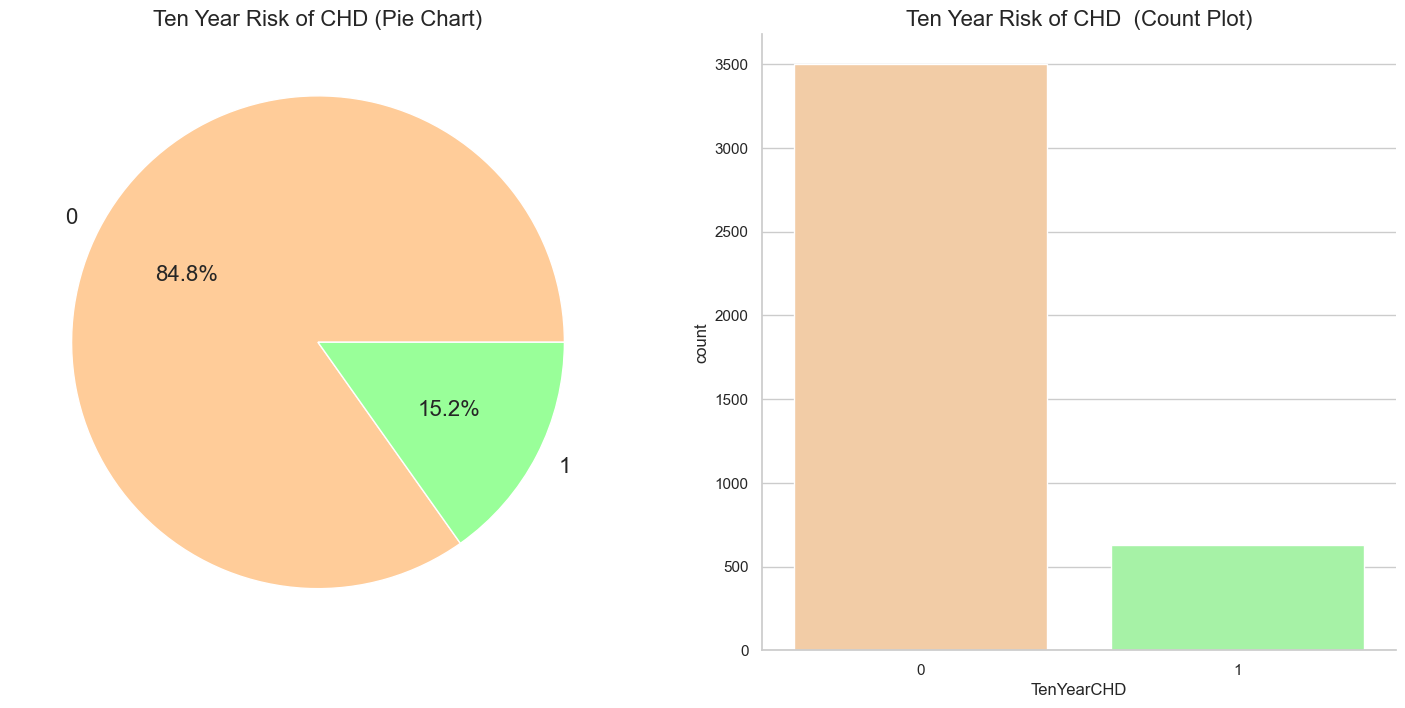

Distribution Based on Target Variable (TenYearCHD):
Individuals with 10-Year Risk of CHD (TenYearCHD = 1):
- Count: 628
- Percentage: 15.19%
Individuals without 10-Year Risk of CHD (TenYearCHD = 0):
- Count: 3505
- Percentage: 84.81%


In [23]:
# The Target (10-year risk of future coronary heart disease) Distribution

# Define custom colors for the pie chart
custom_colors = ['#ffcc99', '#99ff99'] 

# Create a figure with subplots
f, ax = plt.subplots(1, 2, figsize=(18, 8))

# Pie chart with custom colors
db['TenYearCHD'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[0],colors=custom_colors, fontsize=16)
ax[0].set_title('Ten Year Risk of CHD (Pie Chart)', fontsize=16)
ax[0].set_ylabel('')

# Count plot
sns.countplot(x='TenYearCHD', data=db, ax=ax[1], palette=custom_colors)
ax[1].set_title('Ten Year Risk of CHD  (Count Plot)', fontsize=16)

# Customizing styles
sns.set_style('whitegrid')  # Choose a style
sns.despine()  # Remove the top and right spines

plt.show()

# to understand the balance or imbalance between the two categories
# Individuals with a 10-Year Risk of CHD (TenYearCHD = 1):
# This group represents individuals who have a 10-year risk of future coronary heart disease.
# The count and percentage of individuals in this category.
# Individuals without a 10-Year Risk of CHD (TenYearCHD = 0):
# This group represents individuals who do not have a 10-year risk of future coronary heart disease.
# The count and percentage of individuals in this category.

# Calculate the distribution based on the target variable
chd_distribution = db['TenYearCHD'].value_counts()

# Extract counts for both categories
with_chd = chd_distribution[1]
without_chd = chd_distribution[0]

# Calculate percentages
total_count = len(db)
percent_with_chd = (with_chd / total_count) * 100
percent_without_chd = (without_chd / total_count) * 100

# Print the distribution summary
print("Distribution Based on Target Variable (TenYearCHD):")
print("Individuals with 10-Year Risk of CHD (TenYearCHD = 1):")
print("- Count: {}".format(with_chd))
print("- Percentage: {:.2f}%".format(percent_with_chd))
print("Individuals without 10-Year Risk of CHD (TenYearCHD = 0):")
print("- Count: {}".format(without_chd))
print("- Percentage: {:.2f}%".format(percent_without_chd))

In [24]:
# The relationship between age and the target variable
print('- Oldest Patient: The oldest patient in the dataset is of age:',db['Age'].max(),'Years')
print('- Youngest Patient: The youngest patient in the dataset is of age: ',db['Age'].min(),'Years')
print('- Average Age: The average age of the patients in the dataset is approximately :',db['Age'].mean(),'Years')



- Oldest Patient: The oldest patient in the dataset is of age: 70 Years
- Youngest Patient: The youngest patient in the dataset is of age:  32 Years
- Average Age: The average age of the patients in the dataset is approximately : 49.55722235664167 Years


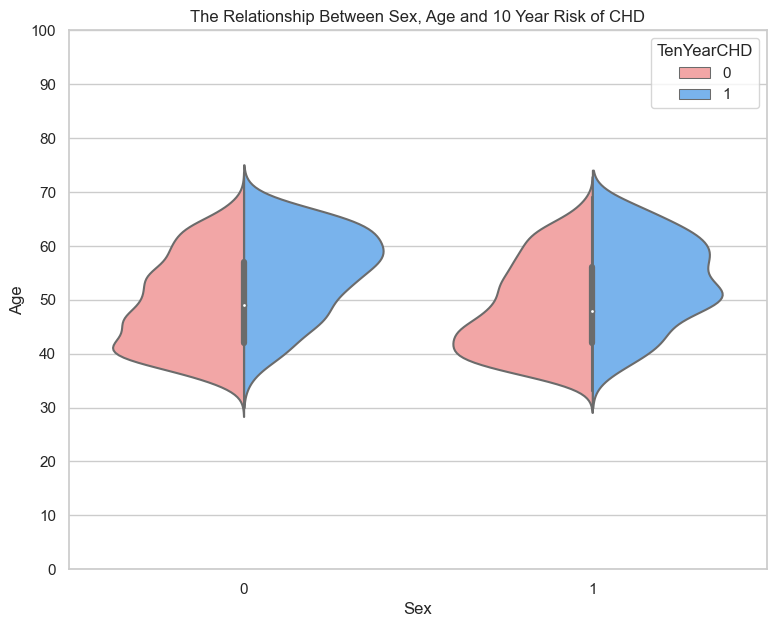

In [25]:
# The relationship between sex, age and the target variable
# Define custom colors for the plot
custom_palette = ['#ff9999', '#66b3ff']

# Set the Seaborn style
sns.set(style="whitegrid")

fig, ax = plt.subplots(figsize =(9, 7))
sns.violinplot(x="Sex", y="Age", hue="TenYearCHD", data=db,split=True, palette=custom_palette)
ax.set_title('The Relationship Between Sex, Age and 10 Year Risk of CHD')
ax.set_yticks(range(0,110,10))
plt.show()

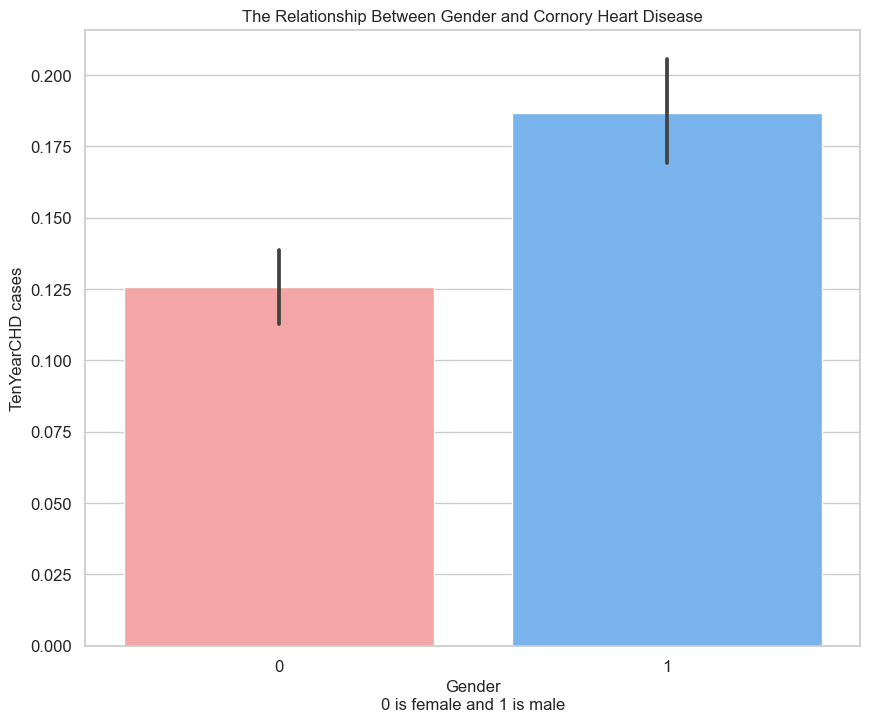

In [26]:
# Graph for the relationship between gender and Cornory Heart Disease
# Define custom colors for the plot
custom_palette = ['#ff9999','#66b3ff']

# Set the Seaborn style
sns.set(style="whitegrid")

plt.figure(figsize=(10,8), facecolor='w')
sns.barplot(x=db["Sex"], y=db["TenYearCHD"], palette=custom_palette)
plt.title("The Relationship Between Gender and Cornory Heart Disease")
plt.xlabel("Gender\n0 is female and 1 is male")
plt.ylabel("TenYearCHD cases")
plt.xticks(size=12)
plt.yticks(size=12)
plt.show()

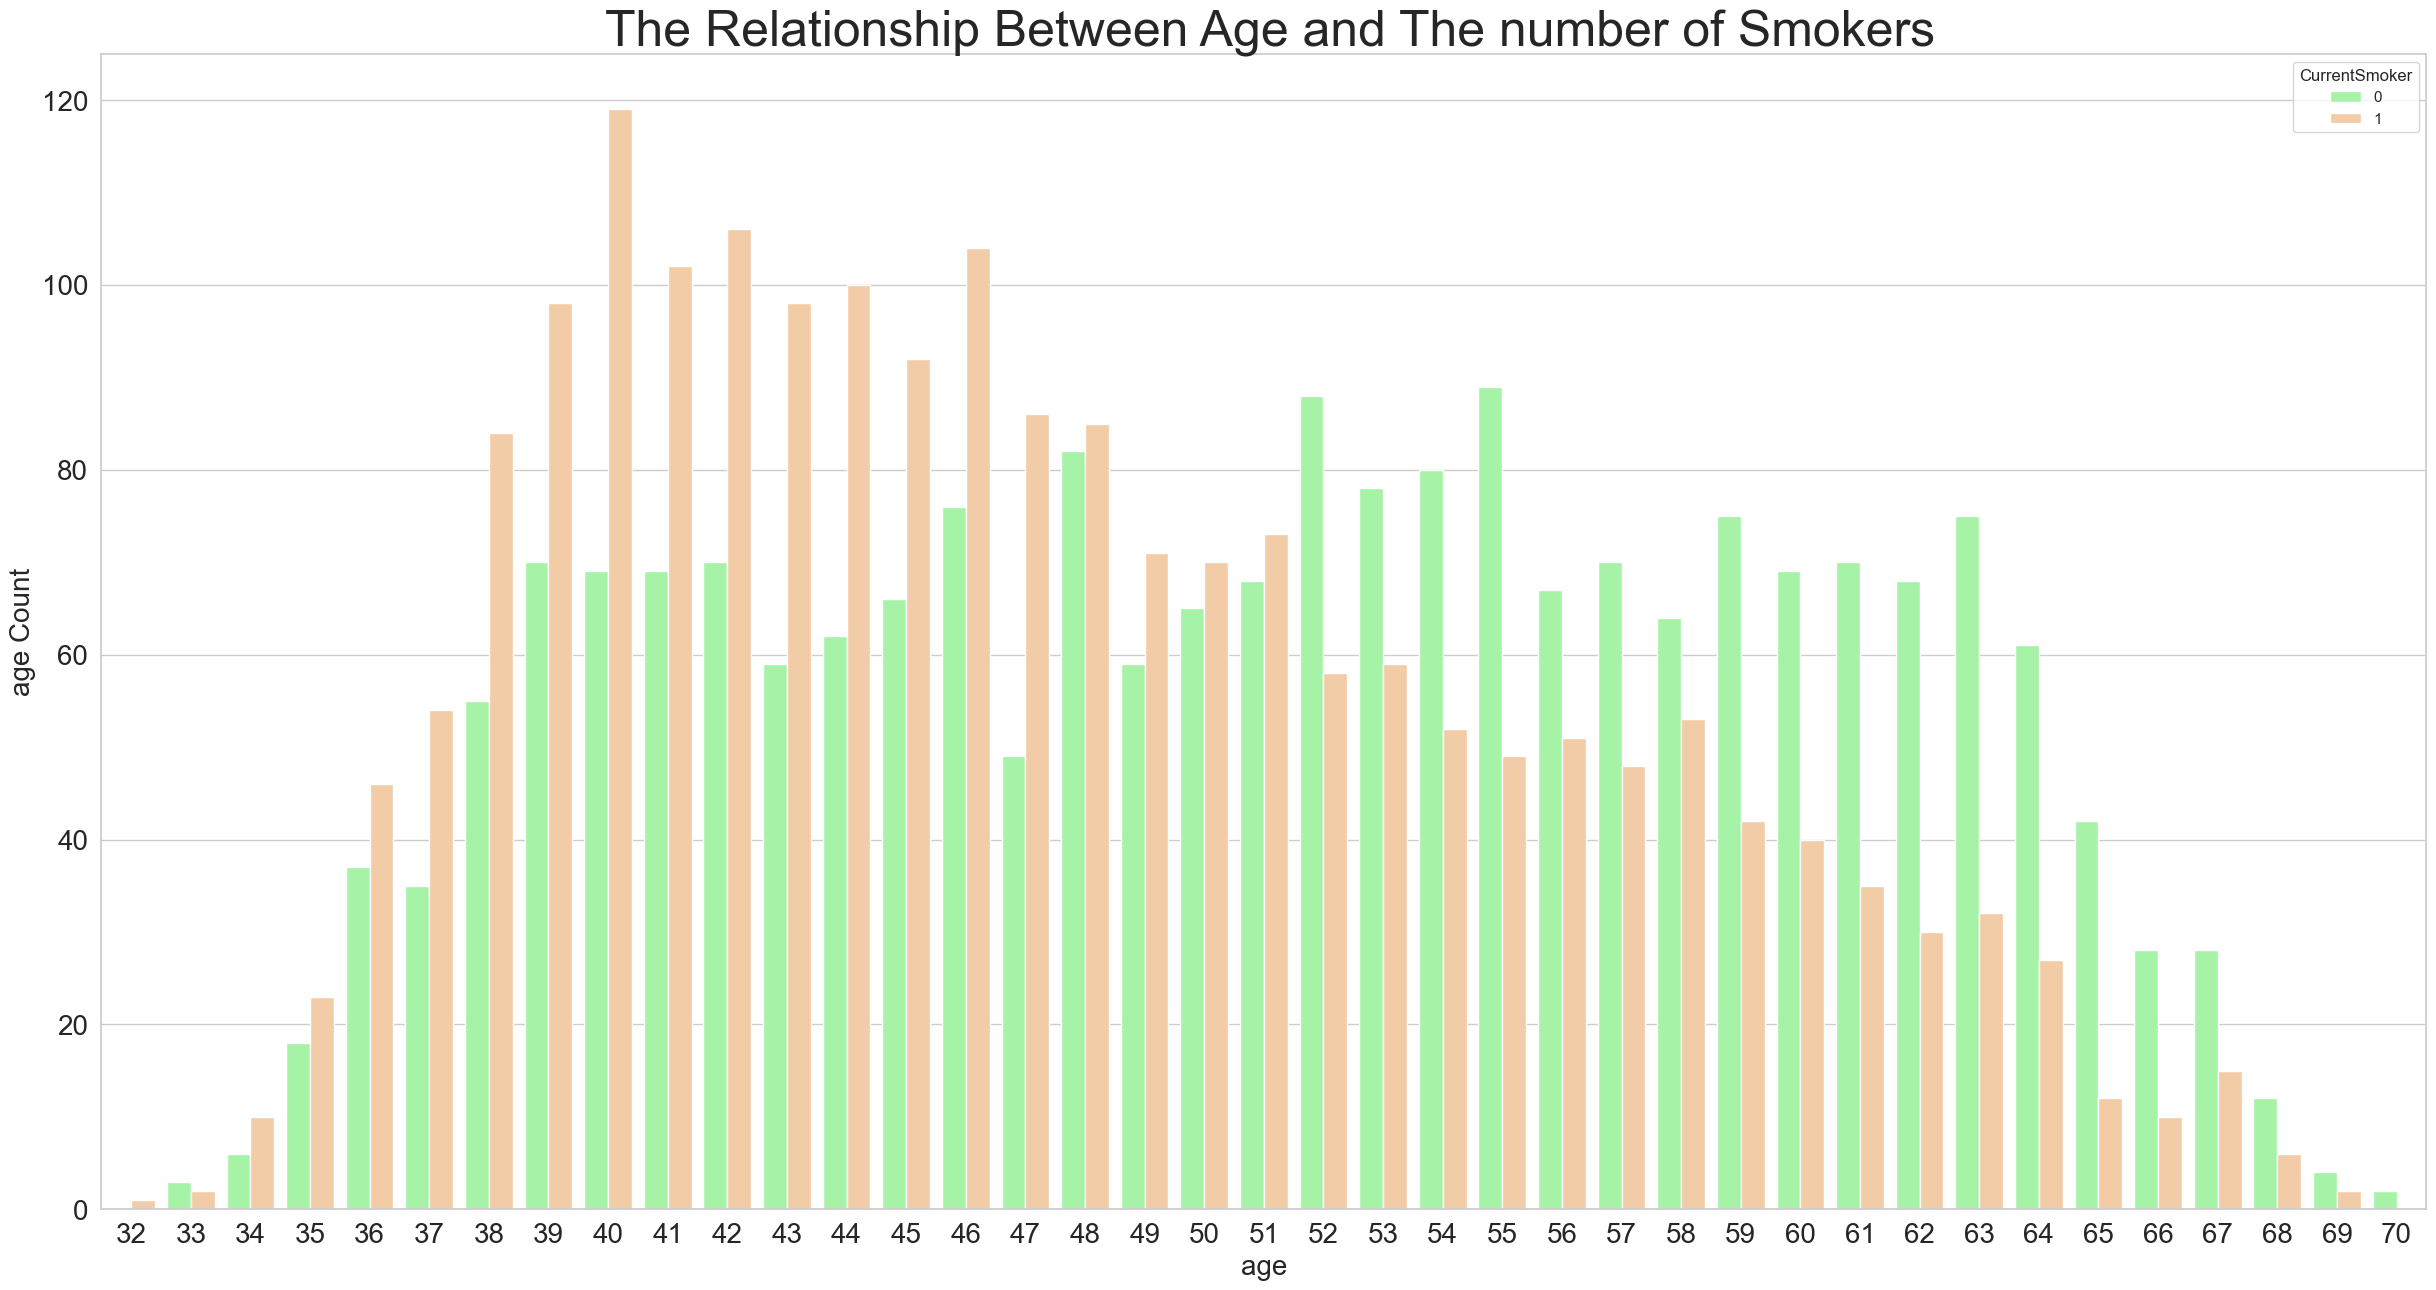

In [27]:
plt.figure(figsize=(30,15), facecolor='w')

# Define custom colors for the plot
custom_palette = ['#99ff99', '#ffcc99']

# Set the Seaborn style
sns.set_style("whitegrid")

sns.countplot(x="Age",data=db,hue="CurrentSmoker", palette=custom_palette)
plt.title(" The Relationship Between Age and The number of Smokers", size=36)
plt.xlabel("age", size=20)
plt.ylabel("age Count", size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.show()


#The count plot you've created visualizes the relationship between age and the number of smokers, with different colors indicating current smokers and non-smokers. Here's what you can interpret from this plot:
#X-Axis (Age): The x-axis represents age.
#Y-Axis (Age Count): The y-axis represents the count of individuals in each age group.
#Hue (CurrentSmoker): The hue differentiates between current smokers (1) and non-smokers (0).

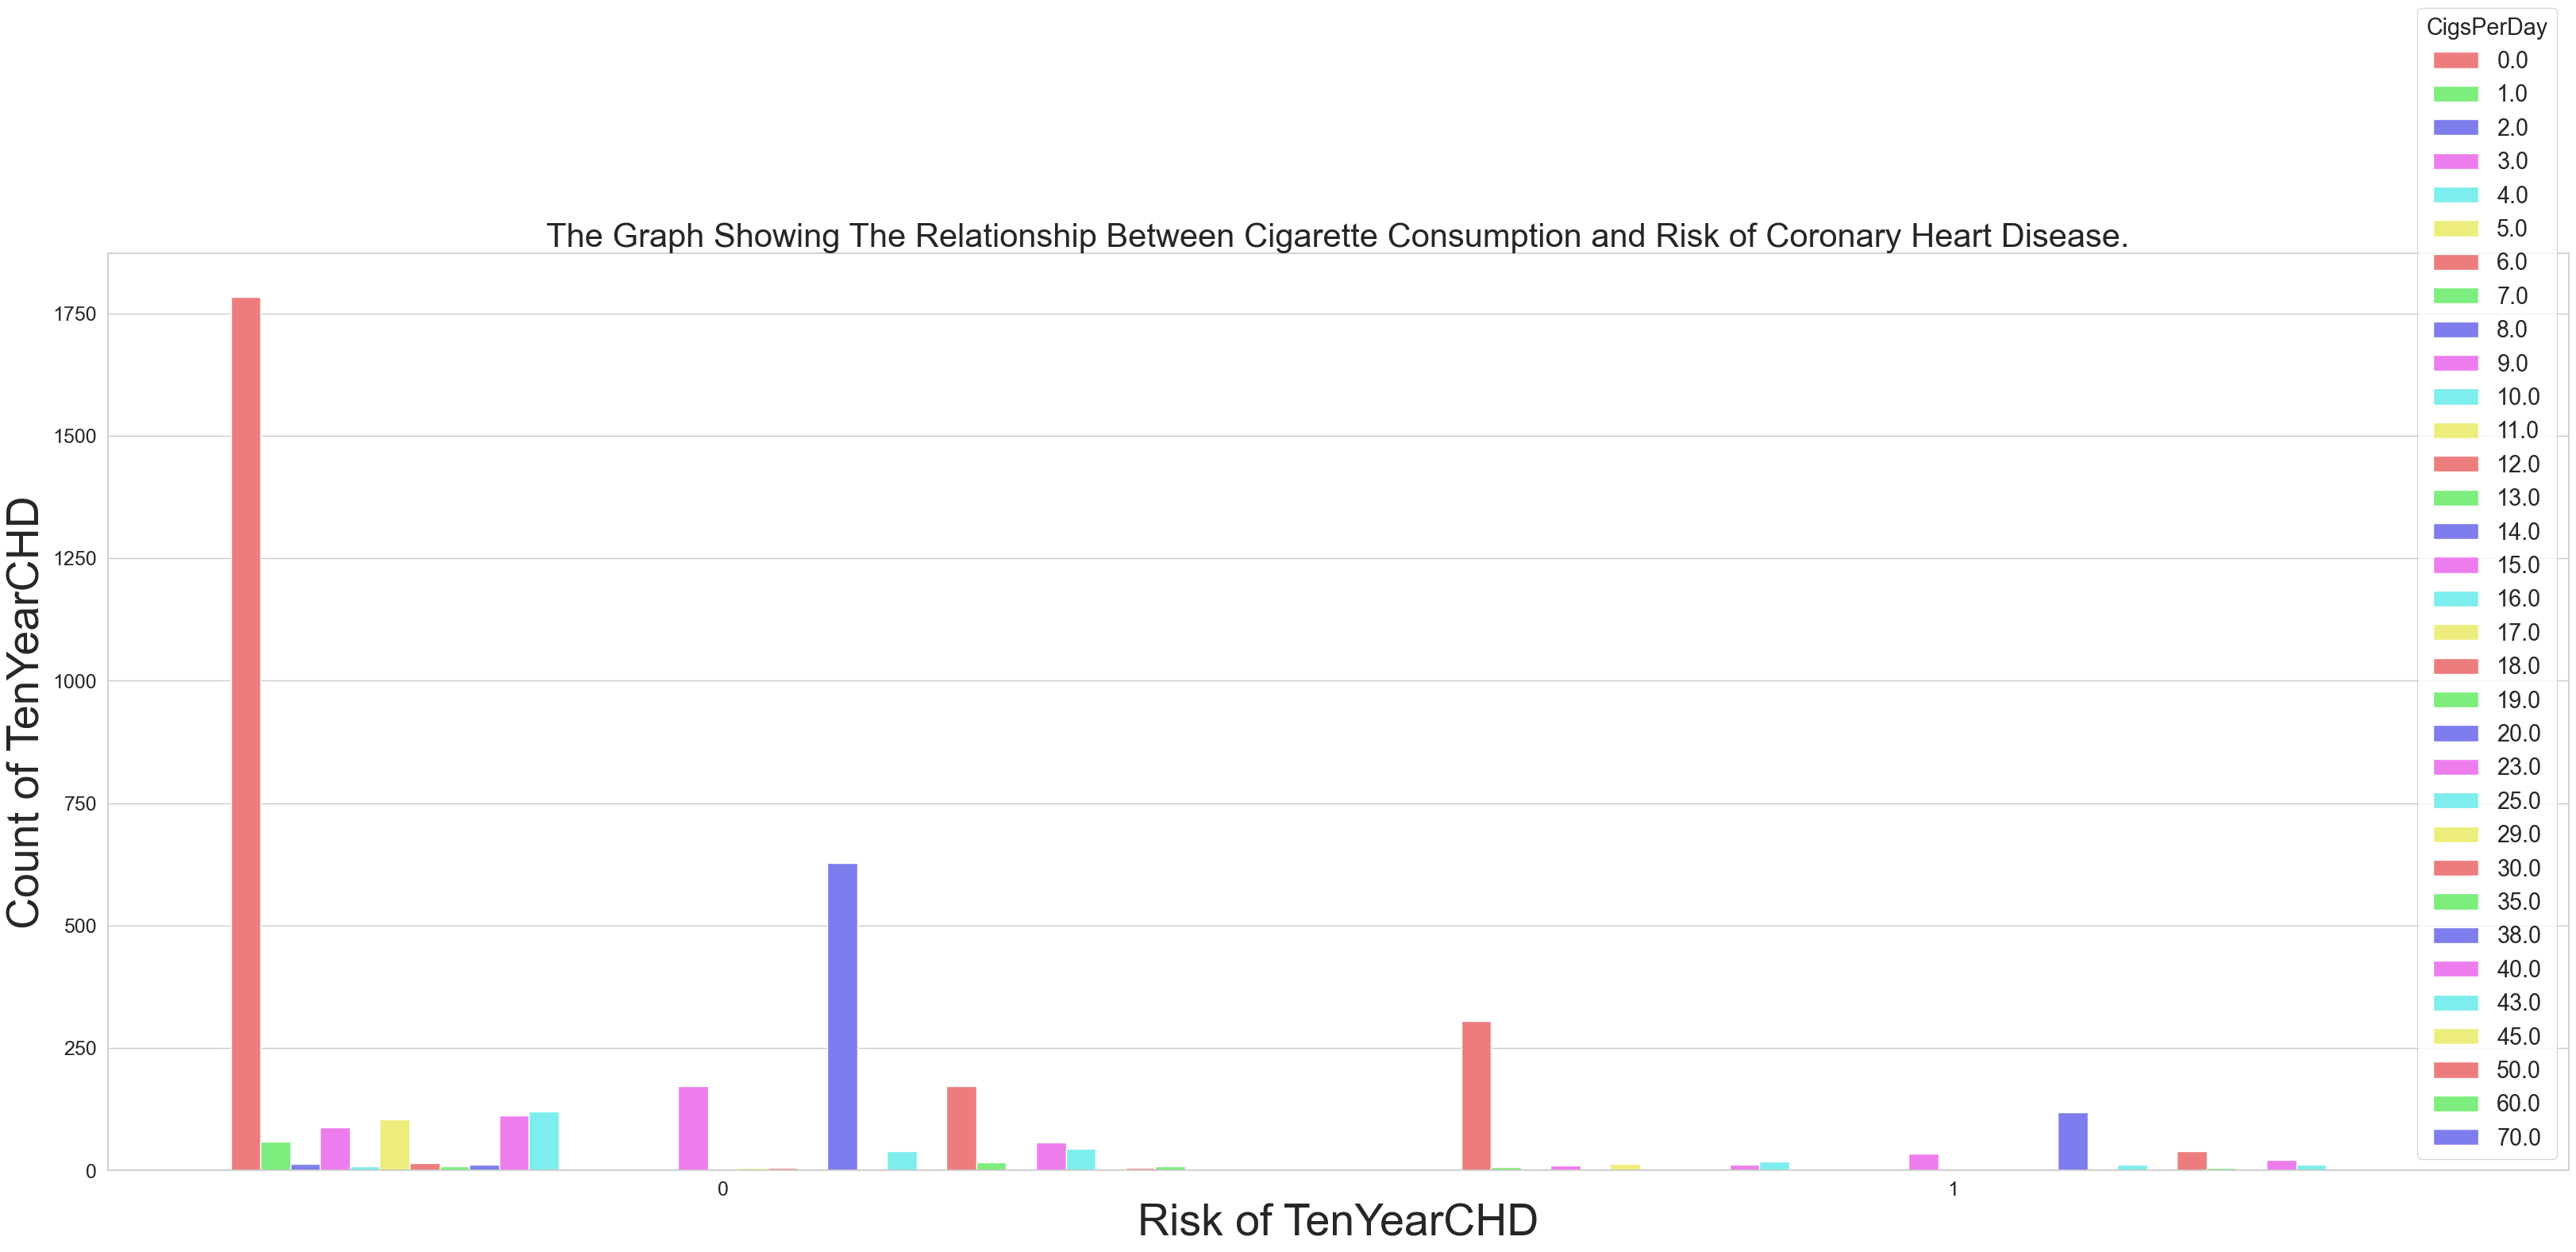

In [28]:
# the distribution of CHD cases (0 or 1) based on different levels of cigarette consumption ('CigsPerDay').

custom_palette = ['#FF6B6B', '#6BFF6B', '#6B6BFF', '#FF6BFF', '#6BFFFF', '#FFFF6B']

# Set the Seaborn style
sns.set(style="whitegrid")

plt.figure(figsize=(40,15), facecolor='w')
sns.countplot(x="TenYearCHD", data=db, hue="CigsPerDay", palette=custom_palette)

# Customize the legend
legend =plt.legend(title='CigsPerDay', fontsize='xx-large', title_fontsize='xx-large')
for label in legend.get_lines():
    label.set_linestyle("-")

plt.title("The Graph Showing The Relationship Between Cigarette Consumption and Risk of Coronary Heart Disease.", size=30)
plt.xlabel("Risk of TenYearCHD", size=40)
plt.ylabel("Count of TenYearCHD", size=40)
plt.xticks(size=18)
plt.yticks(size=18)
plt.show()

/usr/local/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1200x800 with 0 Axes>

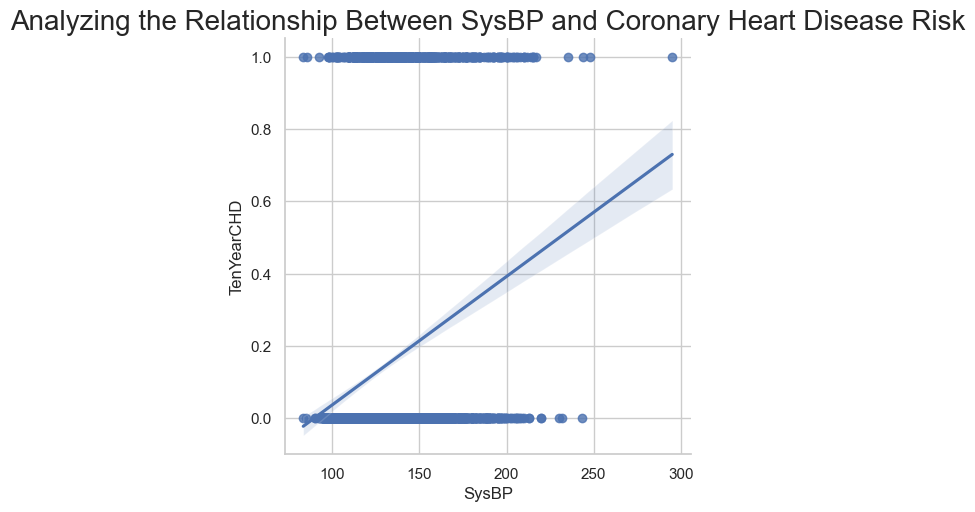

In [29]:
# Create a Scatter Plot

# Set a custom Seaborn style
sns.set(style="whitegrid")

# Create the figure with the specified background color
plt.figure(figsize=(12,8), facecolor='w')

# Create the lmplot with custom palette
sns.lmplot(data=db, x="SysBP", y="TenYearCHD")

# Customize the title
plt.title("Analyzing the Relationship Between SysBP and Coronary Heart Disease Risk", size=20)
plt.show()

/usr/local/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1200x800 with 0 Axes>

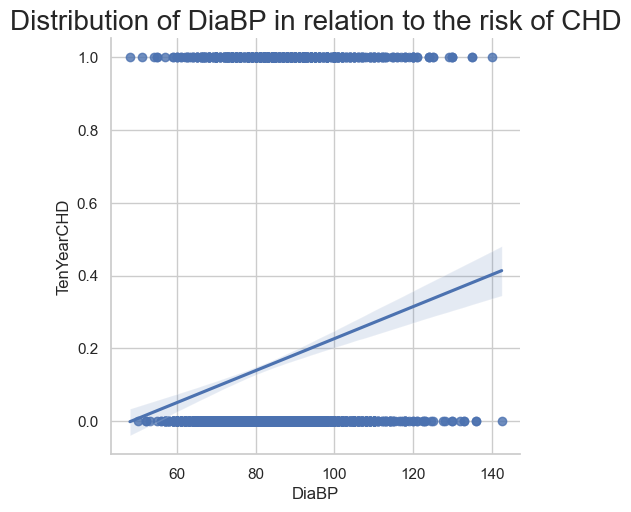

In [30]:
# Define a custom color palette with distinct colors
custom_palette = ['#FFA07A', '#20B2AA']

# Set a custom Seaborn style
sns.set(style="whitegrid")

# Create the figure with the specified background color
plt.figure(figsize=(12, 8), facecolor='w')

# Create the lmplot with the custom palette
sns.lmplot(data=db, x="DiaBP", y="TenYearCHD", palette=custom_palette)

# Customize the title
plt.title("Distribution of DiaBP in relation to the risk of CHD", size=20)

plt.show()

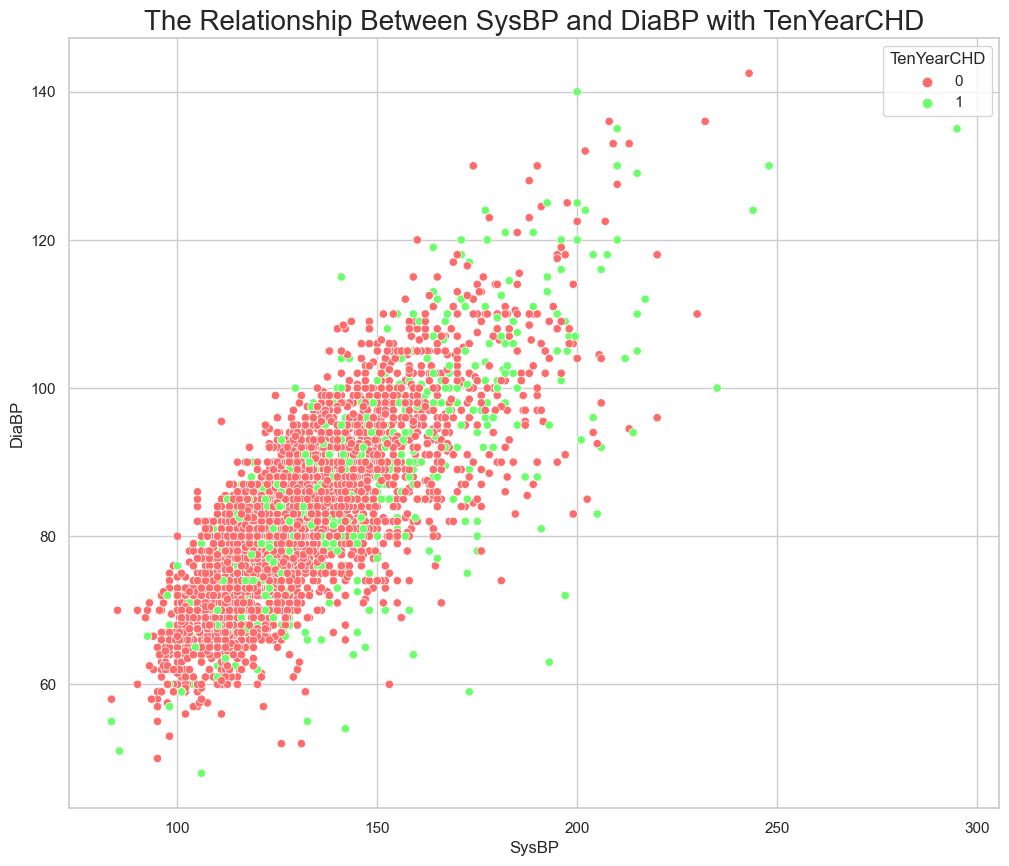

In [31]:
# Define a custom color palette with distinct colors
custom_palette = ['#FF6B6B', '#6BFF6B']

# Set a custom Seaborn style
sns.set(style="whitegrid")

# Create the figure with the specified background color
plt.figure(figsize=(12, 10), facecolor='w')

# Create the scatterplot with custom palette
sns.scatterplot(data=db, x="SysBP", y="DiaBP", hue="TenYearCHD", palette=custom_palette)

# Customize the title
plt.title("The Relationship Between SysBP and DiaBP with TenYearCHD", size=20)

plt.show()

# Detecting and handling outliers

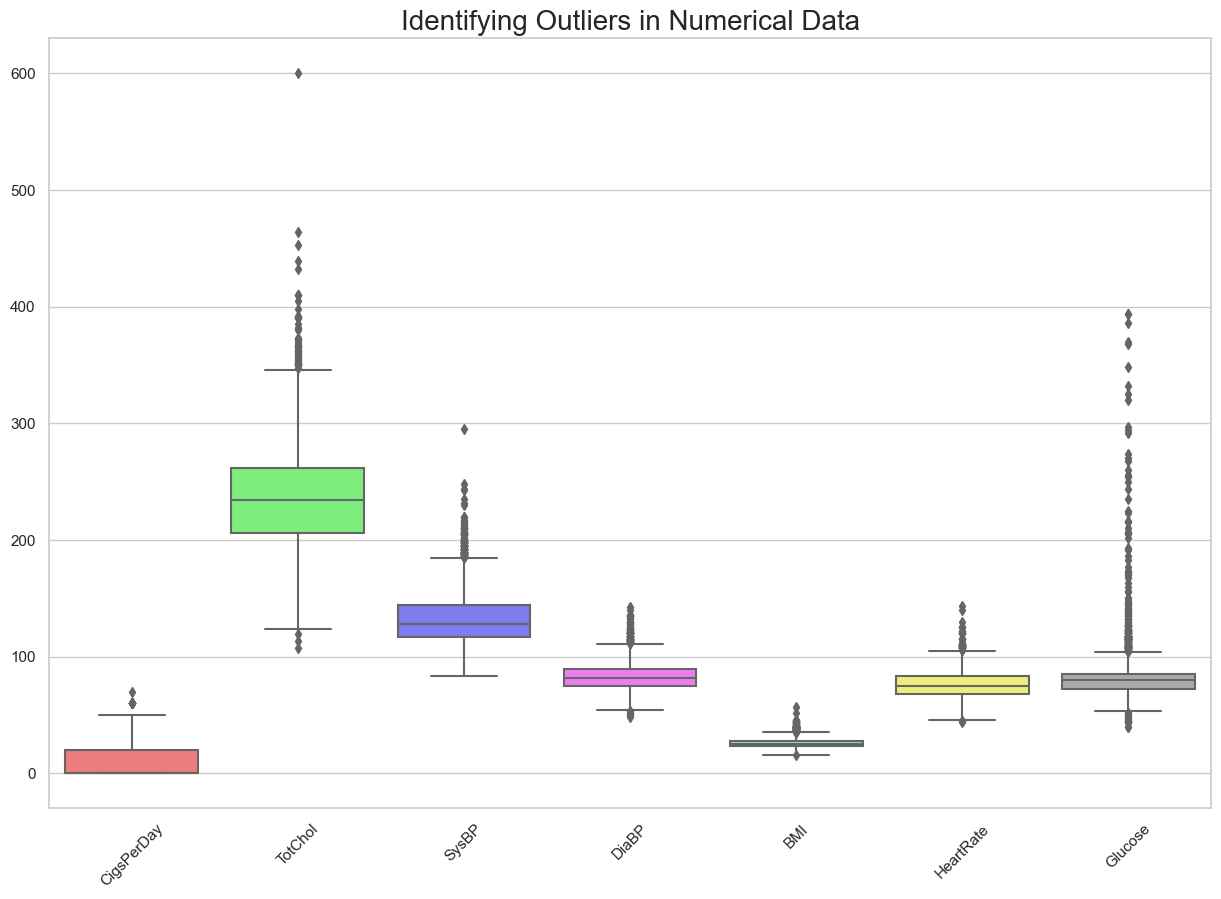

In [32]:
# Define a custom color palette with distinct colors for each numerical column
custom_palette = ['#FF6B6B', '#6BFF6B', '#6B6BFF', '#FF6BFF', '#6BFFFF', '#FFFF6B', '#A9A9A9']

# Set a custom Seaborn style
sns.set(style="whitegrid")

# Create the figure with the specified background color
plt.figure(figsize=(15, 10), facecolor='w')

# Create the boxplot with custom palette for each numerical column
sns.boxplot(data=db[['CigsPerDay', 'TotChol', 'SysBP', 'DiaBP', 'BMI', 'HeartRate', 'Glucose']],
            palette=custom_palette)

# Customize the title
plt.title("Identifying Outliers in Numerical Data", size=20)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.show()

In [33]:
# Remove outliers using the Interquartile Range (IQR) method
# Calculate the first quartile (Q1) using quantile(0.25) and third quartile (Q3) using quantile(0.75)
q1 = db.drop('TenYearCHD', axis=1).quantile(0.25)
q3 = db.drop('TenYearCHD', axis=1).quantile(0.75)
# Calculate the Interquartile Range (IQR)
IQR = q3 - q1

# Define lower and upper bounds for outlier removal
LL = q1 - 1.5 * IQR
UL = q3 + 1.5 * IQR

# Apply outlier removal logic to each numerical column
for col in db.columns[:-1]:  # Exclude the 'TenYearCHD' column
    db = db[(db[col] >= LL[col]) & (db[col] <= UL[col])]

# Note: 'TenYearCHD' column is not included in outlier removal

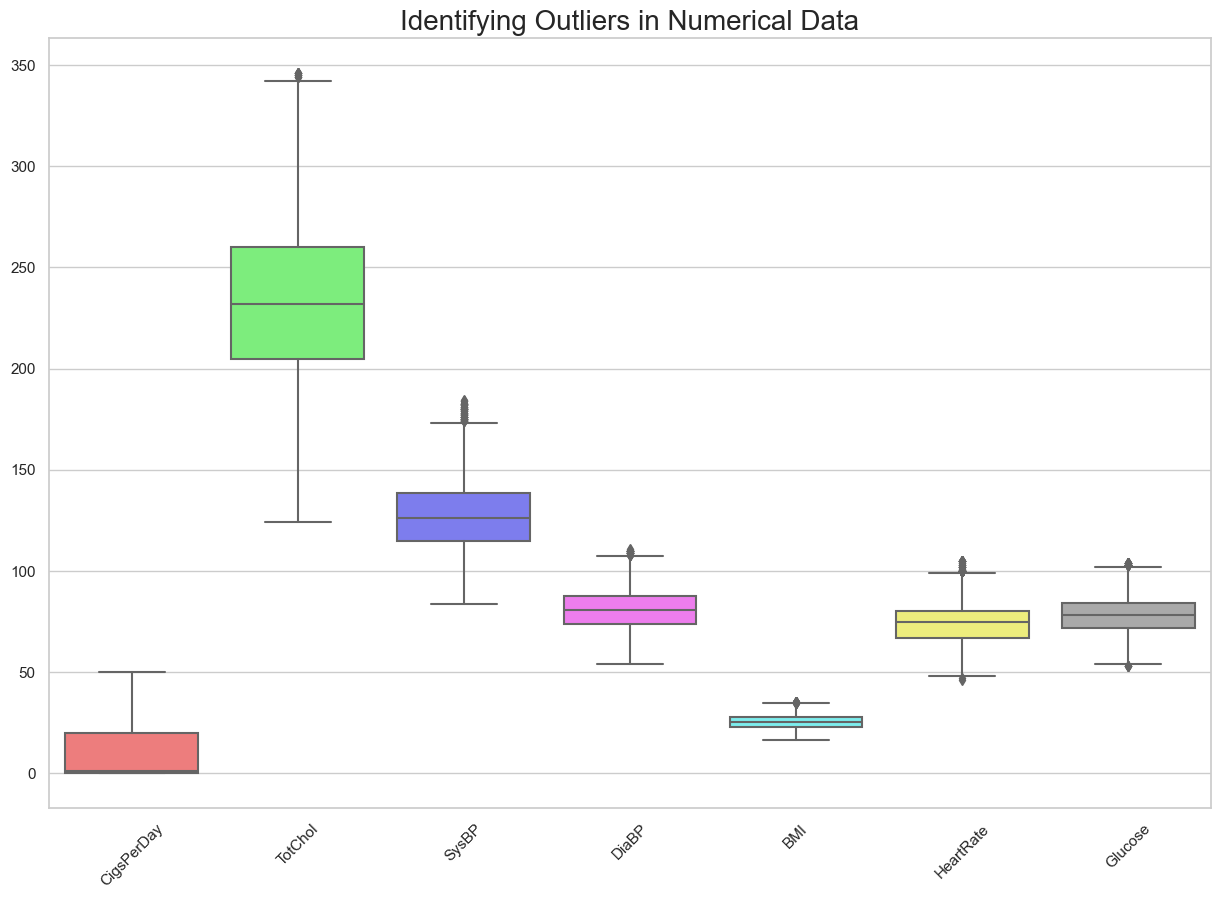

In [34]:
# Recheck outliers 

custom_palette = ['#FF6B6B', '#6BFF6B', '#6B6BFF', '#FF6BFF', '#6BFFFF', '#FFFF6B', '#A9A9A9']

# Set a custom Seaborn style
sns.set(style="whitegrid")

# Create the figure with the specified background color
plt.figure(figsize=(15, 10), facecolor='w')

# Create the boxplot with custom palette for each numerical column
sns.boxplot(data=db[['CigsPerDay', 'TotChol', 'SysBP', 'DiaBP', 'BMI', 'HeartRate', 'Glucose']],
            palette=custom_palette)

# Customize the title
plt.title("Identifying Outliers in Numerical Data", size=20)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.show()

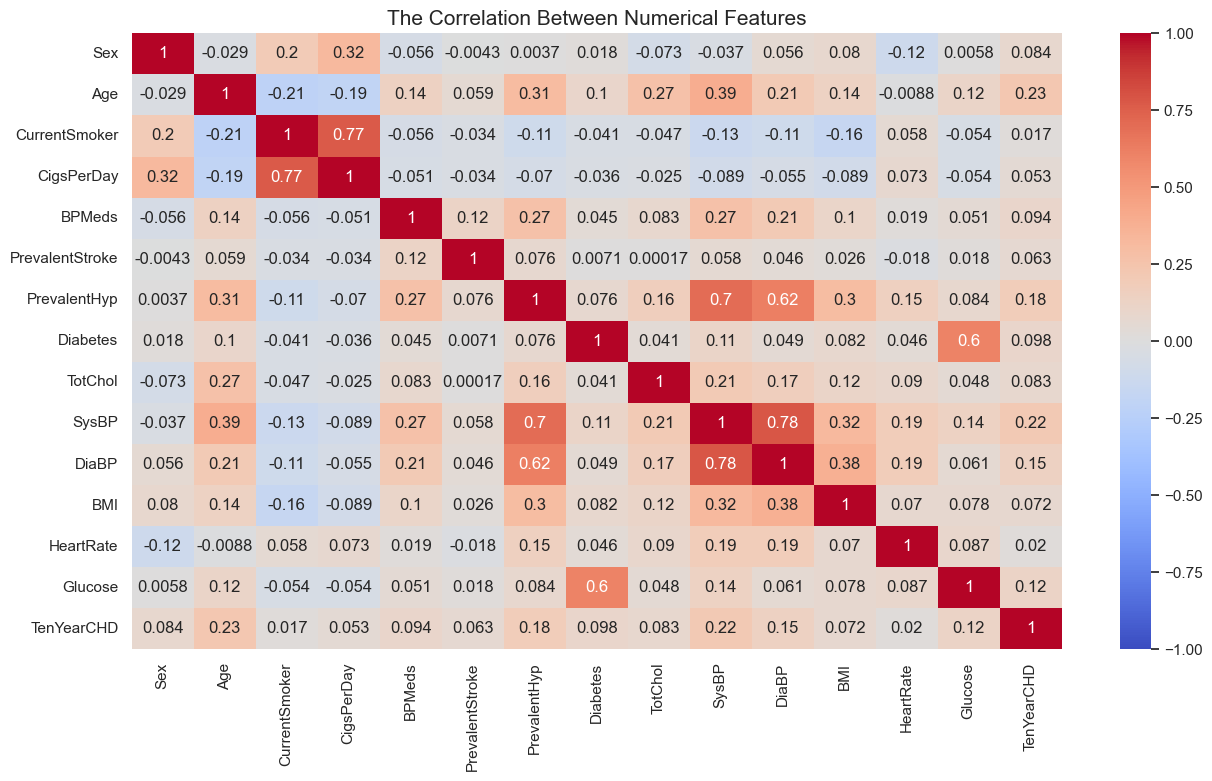

In [35]:
# Set a custom color palette
custom_cmap = sns.color_palette("coolwarm", as_cmap=True)

# Set a custom Seaborn style
sns.set_style("whitegrid")

# Set the figure size
plt.figure(figsize=(15, 8))

# Create the heatmap with custom parameters
sns.heatmap(corr, cmap=custom_cmap, vmax=1.0, vmin=-1.0, annot=True)

# Specify the name of the plot
plt.title('The Correlation Between Numerical Features', size=15)

# Display the plot
plt.show()

# Data Preprocessing 

In [36]:
# Splitting your dataset into features (X) and the target variable (y)
# Assigning all columns except 'TenYearCHD' to X as features and 'TenYearCHD' itself to y as the target variable.
X = db.drop('TenYearCHD', axis = 1)
y = db['TenYearCHD']

In [37]:
# Applying Feature scaling to ensure different features have similar scales
# Initialize the StandardScaler
ss = StandardScaler()
# Fit and transform the feature matrix X
X_s = ss.fit_transform(X)
# Convert the scaled features back to a DataFrame with original column names
X_s = pd.DataFrame(X_s, columns = X.columns)

In [38]:
# Splitting the dataset into training and testing sets
# Specify the input features X_s and the target variable y to be split.
# sets a random seed for reproducibility, ensuring that the same split is generated each time. 
training_x, testing_x, training_y, testing_y = train_test_split(X_s, y, test_size = 0.3, random_state = 10)

# Gaussian Naïve Bayes

In [39]:
# Initialize a Gaussian Naïve Bayes classifier
nb = GaussianNB()
# Fit the classifier to the training data
nb.fit(training_x, training_y)

GaussianNB()

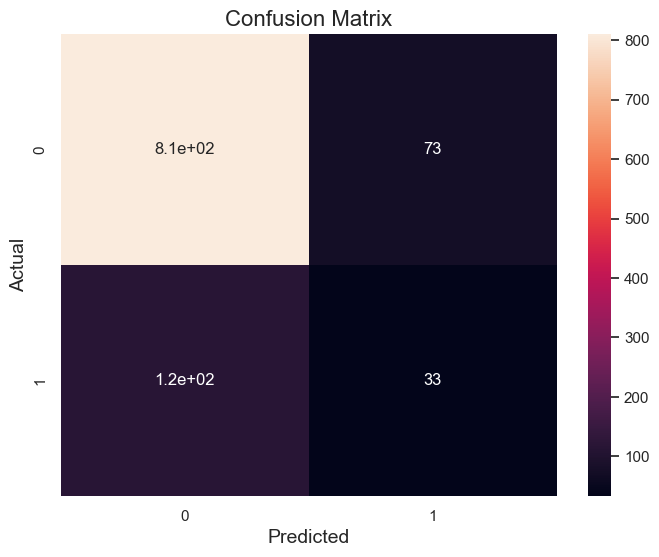

In [40]:
# Use the trained GaussianNB classifier to make predictions on the testing data
y_pred = nb.predict(testing_x)

# Calculate the confusion matrix to evaluate the classifier's performance
confusion_matrix(testing_y, y_pred)

# Create a heatmap with annotations
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(testing_y, y_pred), annot = True)

# Customize the plot
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)

plt.show()

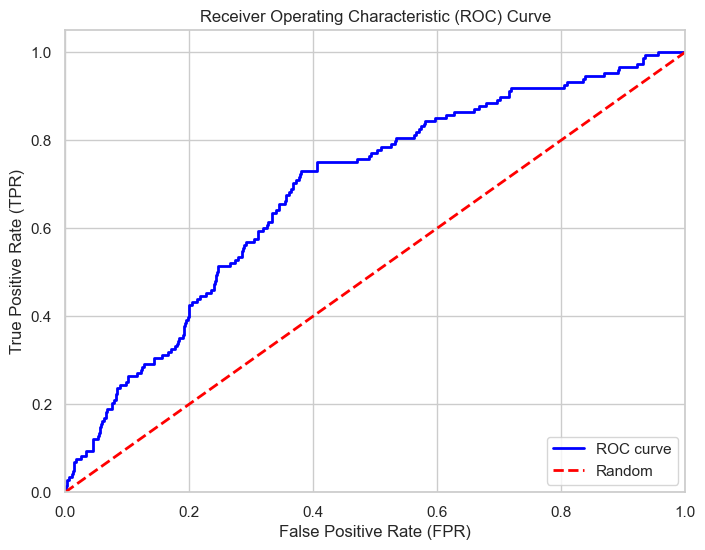

In [41]:
# Calculate the predicted probabilities for the positive class (class 1)
y_prob = nb.predict_proba(testing_x)[:, 1]
# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(testing_y, y_prob)
# Adjust the first threshold to ensure it's lower than any predicted probabilities
thresholds[0] = thresholds[0] - 1
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [42]:
# Predictions and predicted probabilities on the training set
training_y_pred = nb.predict(training_x)
training_y_prob = nb.predict_proba(training_x)[:, 1]
# Calculate ROC AUC, accuracy, precision, F1 score, and recall on the training set
roc_sc_train_NB = roc_auc_score(training_y, training_y_prob)
acc_train_NB = accuracy_score(training_y, training_y_pred)
prec_train_NB = precision_score(training_y, training_y_pred)
f1_train_NB = f1_score(training_y, training_y_pred)
recall_train_NB = recall_score(training_y, training_y_pred)

print("Train Set: ")
print("ROC Score: ", roc_sc_train_NB)
print("Accuracy Score: ", acc_train_NB)
print("Precision Score: ", prec_train_NB)
print("F1 Score: ", f1_train_NB)
print("Recall Score: ", recall_train_NB)

# Predictions and predicted probabilities on the testing set
testing_y_pred = nb.predict(testing_x)
testing_y_prob = nb.predict_proba(testing_x)[:, 1]

roc_sc_test_NB = roc_auc_score(testing_y, testing_y_prob)
acc_test_NB = accuracy_score(testing_y, testing_y_pred)
f1_test_NB = f1_score(testing_y, testing_y_pred)
recall_test_NB = recall_score(testing_y, testing_y_pred)
prec_test_NB = precision_score(testing_y, testing_y_pred)
recall_test_NB = recall_score(testing_y, testing_y_pred)

print("Test Set: ")
print("ROC Score: ", roc_sc_test_NB)
print("Accuracy Score: ", acc_test_NB)
print("Precision Score: ", prec_test_NB)
print("F1 Score: ", f1_test_NB)
print("Recall Score: ", recall_test_NB)

Train Set: 
ROC Score:  0.7023910186039969
Accuracy Score:  0.8257071547420965
Precision Score:  0.2765957446808511
F1 Score:  0.271304347826087
Recall Score:  0.26621160409556316
Test Set: 
ROC Score:  0.6868323589727894
Accuracy Score:  0.8176527643064986
Precision Score:  0.3113207547169811
F1 Score:  0.25984251968503935
Recall Score:  0.22297297297297297


#  K-Nearest Neighbors (KNN) classifier

In [43]:
# create KNN classifier instance and train it on the training dataset
knn = KNeighborsClassifier()
knn.fit(training_x, training_y)

KNeighborsClassifier()

In [44]:
# Training Set
training_y_pred = knn.predict(training_x)
training_y_prob = knn.predict_proba(training_x)[:, 1]

# Calculate Metrics for Training Set
roc_sc_train_KNN = roc_auc_score(training_y, training_y_prob)
acc_train_KNN = accuracy_score(training_y, training_y_pred)
prec_train_KNN = precision_score(training_y, training_y_pred)
f1_train_KNN = f1_score(training_y, training_y_pred)
recall_train_KNN = recall_score(training_y, training_y_pred)

# Print Metrics
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_KNN)
print("Accuracy Score: ", acc_train_KNN)
print("Precision Score: ", prec_train_KNN)
print("F1 Score: ", f1_train_KNN)
print("Recall Score: ", recall_train_KNN)

# Test Set
testing_y_pred = knn.predict(testing_x)
testing_y_prob = knn.predict_proba(testing_x)[:, 1]

roc_sc_test_KNN = roc_auc_score(testing_y, testing_y_prob)
acc_test_KNN = accuracy_score(testing_y, testing_y_pred)
f1_test_KNN = f1_score(testing_y, testing_y_pred)
recall_test_KNN = recall_score(testing_y, testing_y_pred)
prec_test_KNN = precision_score(testing_y, testing_y_pred)

print("\nTest Set Metrics:")
print("ROC Score: ", roc_sc_test_KNN)
print("Accuracy Score: ", acc_test_KNN)
print("Precision Score: ", prec_test_KNN)
print("F1 Score: ", f1_test_KNN)
print("Recall Score: ", recall_test_KNN)

Training Set Metrics:
ROC Score:  0.8881666486129053
Accuracy Score:  0.8856073211314476
Precision Score:  0.618421052631579
F1 Score:  0.2547425474254743
Recall Score:  0.16040955631399317

Test Set Metrics:
ROC Score:  0.6045537326681155
Accuracy Score:  0.8467507274490785
Precision Score:  0.2916666666666667
F1 Score:  0.08139534883720931
Recall Score:  0.0472972972972973


# Hyperparameter Tunning Using GridSearchCV 

In [45]:
# Create a K-Nearest Neighbors (KNN) classifier
knn = KNeighborsClassifier()

# Define a parameter grid for hyperparameter tuning
param = {'n_neighbors': np.arange(1, 25, 2), # Vary the number of neighbors from 1 to 25 (odd numbers)
         'metric': ['euclidean', 'manhattan', 'chebyshev']} # Test different distance metrics

# Create a GridSearchCV object with KNN classifier, parameter grid, cross-validation of 3 folds,
# accuracy as the scoring metric, and parallel processing (-1 for using all available CPU cores)
gsearch = GridSearchCV(estimator=knn, param_grid=param, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object on the training data to find the best hyperparameters
gsearch.fit(training_x, training_y)

# Print the best hyperparameters found by GridSearchCV
print("Best Hyperparameters:")
print(gsearch.best_params_)

Best Hyperparameters:
{'metric': 'chebyshev', 'n_neighbors': 17}


In [46]:
# After performing GridSearchCV, we obtain the best hyperparameters for our KNeighborsClassifier model.
# gsearch.best_params_ contains the best hyperparameters found during the grid search.

# Create a new KNeighborsClassifier instance with the best hyperparameters found by GridSearchCV.
knn = KNeighborsClassifier(**gsearch.best_params_)

# Fit the KNeighborsClassifier model with the training data using the optimized hyperparameters.
knn.fit(training_x, training_y)

KNeighborsClassifier(metric='chebyshev', n_neighbors=17)

In [47]:
# Predict using the KNeighborsClassifier model with GridSearchCV-optimized hyperparameters on the training set.
training_y_pred = knn.predict(training_x)
# Calculate predicted probabilities of the positive class (class 1) for the training set.
training_y_prob = knn.predict_proba(training_x)[:, 1]

# Calculate various performance metrics for the training set.
roc_sc_train_KNN_GSCV = roc_auc_score(training_y, training_y_prob)
acc_train_KNN_GSCV = accuracy_score(training_y, training_y_pred)
prec_train_KNN_GSCV = precision_score(training_y, training_y_pred)
f1_train_KNN_GSCV = f1_score(training_y, training_y_pred)
recall_train_KNN_GSCV = recall_score(training_y, training_y_pred)

# Print the performance metrics for the training set.
print("Train Set Metrics:")
print("ROC Score: ", roc_sc_train_KNN_GSCV)
print("Accuracy Score: ", acc_train_KNN_GSCV)

# Predict using the KNeighborsClassifier model with GridSearchCV-optimized hyperparameters on the testing set.
testing_y_pred = knn.predict(testing_x)
# Calculate predicted probabilities of the positive class (class 1) for the testing set.
testing_y_prob = knn.predict_proba(testing_x)[:, 1]

# Calculate various performance metrics for the testing set.
roc_sc_test_KNN_GSCV = roc_auc_score(testing_y, testing_y_prob)
acc_test_KNN_GSCV = accuracy_score(testing_y, testing_y_pred)
f1_test_KNN_GSCV = f1_score(testing_y, testing_y_pred)
recall_test_KNN_GSCV = recall_score(testing_y, testing_y_pred)
prec_test_KNN_GSCV = precision_score(testing_y, testing_y_pred)

# Print the performance metrics for the testing set.
print("\nTest Set Metrics:")
print("ROC Score: ", roc_sc_test_KNN_GSCV)
print("Accuracy Score: ", acc_test_KNN_GSCV)

Train Set Metrics:
ROC Score:  0.7775878989140258
Accuracy Score:  0.8785357737104825

Test Set Metrics:
ROC Score:  0.6555354901900768
Accuracy Score:  0.8564500484966052


/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Logistic Regression

In [48]:
# Create an instance of LogisticRegression with the 'liblinear' solver
lr = LogisticRegression(solver = 'liblinear')

# Fit the Logistic Regression model on the training data
lr.fit(training_x, training_y)

LogisticRegression(solver='liblinear')

In [49]:
# Use the trained Logistic Regression model to make predictions on the training set
training_y_pred = lr.predict(training_x)
training_y_prob = lr.predict_proba(training_x)[:, 1]

# Calculate various performance metrics on the training set
roc_sc_train_LR = roc_auc_score(training_y, training_y_prob)
acc_train_LR = accuracy_score(training_y, training_y_pred)
prec_train_LR = precision_score(training_y, training_y_pred)
f1_train_LR = f1_score(training_y, training_y_pred)
recall_train_LR = recall_score(training_y, training_y_pred)

# Calculate various performance metrics on the training set
print("Train Set: ")
print("ROC-AUC Score: ", roc_sc_train_LR)
print("Accuracy Score: ", acc_train_LR)
print("Precision Score: ", prec_train_LR)
print("F1 Score: ", f1_train_LR)
print("Recall Score: ", recall_train_LR)

# Use the trained Logistic Regression model to make predictions on the testing set
testing_y_pred = lr.predict(testing_x)
testing_y_prob = lr.predict_proba(testing_x)[:, 1]

# Calculate various performance metrics on the testing set
roc_sc_test_LR = roc_auc_score(testing_y, testing_y_prob)
acc_test_LR = accuracy_score(testing_y, testing_y_pred)
f1_test_LR = f1_score(testing_y, testing_y_pred)
recall_test_LR = recall_score(testing_y, testing_y_pred)
prec_test_LR = precision_score(testing_y, testing_y_pred)

# Print performance metrics for the testing set
print("\nTest Set: ")
print("ROC-AUC Score: ", roc_sc_test_LR)
print("Accuracy Score: ", acc_test_LR)
print("Precision Score: ", prec_test_LR)
print("F1 Score: ", f1_test_LR)
print("Recall Score: ", recall_test_LR)

Train Set: 
ROC-AUC Score:  0.7295816000375086
Accuracy Score:  0.8793677204658902
Precision Score:  0.6153846153846154
F1 Score:  0.05228758169934641
Recall Score:  0.027303754266211604

Test Set: 
ROC-AUC Score:  0.7040647669186741
Accuracy Score:  0.8545101842870999
Precision Score:  0.25
F1 Score:  0.013157894736842106
Recall Score:  0.006756756756756757


# Evaluation Metrics

In [50]:
First_model = pd.DataFrame({'ROC Train': [roc_sc_train_NB, roc_sc_train_KNN, roc_sc_train_KNN_GSCV, roc_sc_train_LR],
                   'Accuracy Train': [acc_train_NB, acc_train_KNN, acc_train_KNN_GSCV, acc_train_LR],
                   'F1 Score Train': [f1_train_NB, f1_train_KNN, f1_train_KNN_GSCV, f1_train_LR],
                   'Recall Train': [recall_train_NB, recall_train_KNN, recall_train_KNN_GSCV, recall_train_LR],
                   'Precision Train': [prec_train_NB, prec_train_KNN, prec_train_KNN_GSCV, prec_train_LR],
                   
                   'ROC Test': [roc_sc_test_NB, roc_sc_test_KNN, roc_sc_test_KNN_GSCV, roc_sc_test_LR],
                   'Accuracy Test': [acc_test_NB, acc_test_KNN, acc_test_KNN_GSCV, acc_test_LR],
                   'F1 Score Test': [f1_test_NB, f1_test_KNN, f1_test_KNN_GSCV, f1_test_LR],
                   'Recall Test': [recall_test_NB, recall_test_KNN, recall_test_KNN_GSCV, recall_test_LR],
                   'Precision Test': [prec_test_NB, prec_test_KNN, prec_test_KNN_GSCV, prec_test_LR]},
                  index = ['Naive Bayes', 'KNeighbors Classifier', 'KNeighbors Classifier GSCV', 'Logistic Regression'])

# Display the First_model DataFrame
First_model

,ROC Train,Accuracy Train,F1 Score Train,Recall Train,Precision Train,ROC Test,Accuracy Test,F1 Score Test,Recall Test,Precision Test
Naive Bayes,0.702391,0.825707,0.271304,0.266212,0.276596,0.686832,0.817653,0.259843,0.222973,0.311321
KNeighbors Classifier,0.888167,0.885607,0.254743,0.160410,0.618421,0.604554,0.846751,0.081395,0.047297,0.291667
KNeighbors Classifier GSCV,0.777588,0.878536,0.013514,0.006826,0.666667,0.655535,0.856450,0.000000,0.000000,0.000000
Logistic Regression,0.729582,0.879368,0.052288,0.027304,0.615385,0.704065,0.854510,0.013158,0.006757,0.250000


# Over Sampling 

In [51]:
# Split the dataset into features (X) and the target variable (y
X = db.drop('TenYearCHD', axis = 1)
#Target variable ('TenYearCHD' column)
y = db['TenYearCHD']
# count the unique values in the 'TenYearCHD' column
db['TenYearCHD'].value_counts()


TenYearCHD
0    2994
1     441
Name: count, dtype: int64

In [52]:
# Synthetic Minority Over-sampling Technique 
# Create an instance of the SMOTE (Synthetic Minority Over-sampling Technique) class.
# Specify 'sampling_strategy' as 'minority' to balance the class distribution.
# Set 'random_state' for reproducibility of the resampling process.
smote = SMOTE(sampling_strategy = 'minority', random_state = 1)

# Apply SMOTE to the feature matrix 'X' and target variable 'y'.
# Resample the minority class to match the number of samples in the majority class.
x_sampled, y_sampled= smote.fit_resample(X, y)

# 'x_sampled' now contains the resampled features, and 'y_sampled' contains the corresponding target labels.

# Calculate and print the length of class 0 in y_sampled
print('len0:', len(y_sampled[y_sampled == 0]))
# Calculate and print the length of class 1 in y_sampled
print('len1:', len(y_sampled[y_sampled == 1]))

# Split the resampled data into training and testing sets
# x_sampled and y_sampled are the resampled feature and target data, respectively
# test_size = 0.3 indicates that 30% of the data will be used for testing, and 70% for training
# random_state is set for reproducibility, so you get the same split each time you run the code
training_x, testing_x, training_y, testing_y = train_test_split(x_sampled, y_sampled, test_size = 0.3, random_state = 42)

len0: 2994
len1: 2994


# Decision Tree Classifier

In [53]:
# Decision Tree Classifier
# In this technique, the attributes will be arranged in a multi-level tree-like structure, where the most significant attributes are placed at the roots and the least significant attributes are placed at the leaves.
# Here significance is calculated by the entropy of the attributes.
# The decision will be taken according to the traversal of the tree for the given input.

# Instantiate a DecisionTreeClassifier model
dtree = DecisionTreeClassifier()

# Train the model on the training data
dtree.fit(training_x, training_y)

# Calculate feature importances
imp = pd.DataFrame({"Features": training_x.columns, "Importance": dtree.feature_importances_})

# Sort the features by importance
imp.sort_values(by = 'Importance')

,Features,Importance
4,BPMeds,0.000000
5,PrevalentStroke,0.000000
7,Diabetes,0.000000
6,PrevalentHyp,0.006752
0,Sex,0.007559
2,CurrentSmoker,0.060730
10,DiaBP,0.091108
11,BMI,0.092431
12,HeartRate,0.095835
9,SysBP,0.104788


In [54]:
# This code will drop the columns from the DataFrame "x_sampled," 
# the modified DataFrame will be stored in the variable "x_sampled
# These features are not important to the 
x_sampled = x_sampled.drop(['BPMeds', 'PrevalentStroke', 'Diabetes'], axis = 1)

In [55]:
# Use the resampled data after dropping features not important to the analysis
# Using the new dataframe x_sampled

# test size of 30% of the data. 
# The random_state parameter is set to 42
training_x, testing_x, training_y, testing_y = train_test_split(x_sampled, y_sampled, test_size = 0.3, random_state = 42)

In [56]:
# create a Decision Tree Classifier model.
dtree = DecisionTreeClassifier()

# Fit the Decision Tree model to the training data.
dtree.fit(training_x, training_y)

DecisionTreeClassifier()

In [57]:
# Use the trained model to make predictions on the training dataset
training_y_pred = dtree.predict(training_x)
training_y_prob = dtree.predict_proba(training_x)[:, 1]

roc_sc_train_dt = roc_auc_score(training_y, training_y_prob)
acc_train_dt = accuracy_score(training_y, training_y_pred)
prec_train_dt = precision_score(training_y, training_y_pred)
f1_train_dt = f1_score(training_y, training_y_pred)
recall_train_dt = recall_score(training_y, training_y_pred)

# Print performance metrics for the training set
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_dt)
print("Accuracy Score: ", acc_train_dt)
print("Precision Score: ", prec_train_dt)
print("F1 Score: ", f1_train_dt)
print("Recall Score: ", recall_train_dt)

# Use the trained model to make predictions on the testing dataset
testing_y_pred = dtree.predict(testing_x)
testing_y_prob = dtree.predict_proba(testing_x)[:, 1]

roc_sc_test_dt = roc_auc_score(testing_y, testing_y_prob)
acc_test_dt = accuracy_score(testing_y, testing_y_pred)
f1_test_dt = f1_score(testing_y, testing_y_pred)
prec_test_dt = precision_score(training_y, training_y_pred)
recall_test_dt = recall_score(testing_y, testing_y_pred)

# Print performance metrics for the testing set
print("\nTesting Set Metrics:")
print("ROC Score: ", roc_sc_test_dt)
print("Accuracy Score: ", acc_test_dt)
print("Precision Score: ", prec_test_dt)
print("F1 Score: ", f1_test_dt)
print("Recall Score: ", recall_test_dt)

Training Set Metrics:
ROC Score:  1.0
Accuracy Score:  1.0
Precision Score:  1.0
F1 Score:  1.0
Recall Score:  1.0

Testing Set Metrics:
ROC Score:  0.7986564870358436
Accuracy Score:  0.7974401780745687
Precision Score:  1.0
F1 Score:  0.8036677454153183
Recall Score:  0.8494868871151653


# Tuning parameters with GridSearchCV


In [58]:
# Create a DecisionTreeClassifier with a specified random_state
dtree = DecisionTreeClassifier(random_state = 1)

# Define the hyperparameter grid to search over
param = {'criterion': ["gini", "entropy"],
         'max_depth': [2,3,4,5,6],
         'min_samples_split': [2,3,4,5,6,7,8,9,10],
         'min_samples_leaf': [1,2,3,4,5,6,7,8,9,10]}

# Create a GridSearchCV object with 3-fold cross-validation
gsearch = GridSearchCV(estimator = dtree, param_grid = param, cv = 3)

# Fit the GridSearchCV object on the training data
gsearch.fit(training_x, training_y)

# Print the best hyperparameters found by GridSearchCV
print("Best Hyperparameters:")
print(gsearch.best_params_)

Best Hyperparameters:
{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [59]:
# Create a DecisionTreeClassifier with the best hyperparameters found by GridSearchCV
dtree = DecisionTreeClassifier(**gsearch.best_params_)

# Fit the DecisionTreeClassifier on the training data
dtree.fit(training_x, training_y)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=2, min_samples_split=5)

In [60]:
# Use the trained model to make predictions on the training dataset
training_y_pred = dtree.predict(training_x)
training_y_prob = dtree.predict_proba(training_x)[:, 1]

# Calculate performance metrics for the training set
roc_sc_train_GSCV = roc_auc_score(training_y, training_y_prob)
acc_train_GSCV = accuracy_score(training_y, training_y_pred)
f1_train_GSCV = f1_score(training_y, training_y_pred)
recall_train_GSCV = recall_score(training_y, training_y_pred)
prec_train_GSCV = precision_score(training_y, training_y_pred)

# Print performance metrics for the training set
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_GSCV)
print("Accuracy Score: ", acc_train_GSCV)

# Use the trained model to make predictions on the testing dataset
testing_y_pred = dtree.predict(testing_x)
testing_y_prob = dtree.predict_proba(testing_x)[:, 1]

# Calculate performance metrics for the testing set
roc_sc_test_GSCV = roc_auc_score(testing_y, testing_y_prob)
acc_test_GSCV = accuracy_score(testing_y, testing_y_pred)
f1_test_GSCV = f1_score(testing_y, testing_y_pred)
recall_test_GSCV = recall_score(testing_y, testing_y_pred)
prec_test_GSCV = precision_score(testing_y, testing_y_pred)

# Print performance metrics for the testing set
print("\nTesting Set Metrics:")
print("ROC Score: ", roc_sc_test_GSCV)
print("Accuracy Score: ", acc_test_GSCV)

Training Set Metrics:
ROC Score:  0.830708973461381
Accuracy Score:  0.7506561679790026

Testing Set Metrics:
ROC Score:  0.7728366218829013
Accuracy Score:  0.6967167501391207


# Randomized Search CV

In [61]:
# Create a Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state = 1)

# Define the hyperparameter distributions using sp_randint
param = {'criterion': ["gini", "entropy"],
         'max_depth': sp_randint(2,25), # Randomly sample max_depth from 2 to 25
         'min_samples_split': sp_randint(2,25),# Randomly sample min_samples_split from 2 to 25
         'min_samples_leaf': sp_randint(2,25)} # Randomly sample min_samples_leaf from 2 to 25

# Create Randomized Search CV object
random_search = RandomizedSearchCV(
    estimator=dtree,  # Decision Tree Classifier
    param_distributions=param,  # Hyperparameter distributions
    cv=3,  # Cross-validation folds
    random_state=42,  # Random seed for reproducibility
    n_jobs=-1,  # Use all available CPU cores
    scoring='roc_auc',  # Evaluation metric
    n_iter=100  # Number of parameter settings that are sampled
)
# Fit Randomized Search CV on your training data
random_search.fit(training_x, training_y)

# Get the best hyperparameters from the randomized search
best_params = random_search.best_params_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 12, 'min_samples_split': 22}


In [62]:
# Create a Decision Tree Classifier with the best hyperparameters from Randomized Search CV
dtree = DecisionTreeClassifier(**best_params)
# Fit the Decision Tree Classifier on the training data
dtree.fit(training_x, training_y)

DecisionTreeClassifier(max_depth=12, min_samples_leaf=12, min_samples_split=22)

In [63]:
# Use the trained model to make predictions on the training dataset
training_y_pred = dtree.predict(training_x)
training_y_prob = dtree.predict_proba(training_x)[:, 1]

# Calculate performance metrics for the training set
roc_sc_train_RSCV = roc_auc_score(training_y, training_y_prob)
acc_train_RSCV = accuracy_score(training_y, training_y_pred)
f1_train_RSCV = f1_score(training_y, training_y_pred)
recall_train_RSCV = recall_score(training_y, training_y_pred)
prec_train_RSCV = precision_score(training_y, training_y_pred)

# Print performance metrics for the training set
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_RSCV)
print("Accuracy Score: ", acc_train_RSCV)

# Use the trained model to make predictions on the testing dataset
testing_y_pred = dtree.predict(testing_x)
testing_y_prob = dtree.predict_proba(testing_x)[:, 1]

# Calculate performance metrics for the testing set
roc_sc_test_RSCV = roc_auc_score(testing_y, testing_y_prob)
acc_test_RSCV = accuracy_score(testing_y, testing_y_pred)
f1_test_RSCV = f1_score(testing_y, testing_y_pred)
recall_test_RSCV = recall_score(testing_y, testing_y_pred)
prec_test_RSCV = precision_score(testing_y, testing_y_pred)


# Print performance metrics for the testing set
print("\nTesting Set Metrics:")
print("ROC Score: ", roc_sc_test_RSCV)
print("Accuracy Score: ", acc_test_RSCV)

Training Set Metrics:
ROC Score:  0.9350598475217153
Accuracy Score:  0.8484848484848485

Testing Set Metrics:
ROC Score:  0.8301794655693817
Accuracy Score:  0.7529215358931552


In [64]:
# Create a DataFrame to store performance metrics for Decision Tree models
second_model = pd.DataFrame({
    'Accuracy_Train': [roc_sc_train_dt, roc_sc_train_GSCV, roc_sc_train_RSCV],
    'AUC_Train': [acc_train_dt, acc_train_GSCV, acc_train_RSCV],
    'F1_Score_Train': [f1_train_dt, f1_train_GSCV, f1_train_RSCV],
    'Recall_Train': [recall_train_dt, recall_train_GSCV, recall_train_RSCV],
    'Precision_Train': [prec_train_dt, prec_train_RSCV, prec_train_GSCV],
    'Accuracy': [acc_test_dt, acc_test_GSCV, acc_test_RSCV],
    'AUC': [roc_sc_test_dt, roc_sc_test_GSCV, roc_sc_test_RSCV],
    'F1_Score': [f1_test_dt, f1_test_GSCV, f1_test_RSCV],
    'Recall': [recall_test_dt, recall_test_GSCV, recall_test_RSCV],
    'Precision': [prec_test_dt, prec_test_RSCV, prec_test_GSCV]
},
index=['Decision Tree', 'Decision Tree GSCV', 'Decision Tree RSCV'])
second_model


,Accuracy_Train,AUC_Train,F1_Score_Train,Recall_Train,Precision_Train,Accuracy,AUC,F1_Score,Recall,Precision
Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,0.797440,0.798656,0.803668,0.849487,1.000000
Decision Tree GSCV,0.830709,0.750656,0.773663,0.843647,0.852186,0.696717,0.772837,0.715998,0.783352,0.738699
Decision Tree RSCV,0.935060,0.848485,0.849562,0.846953,0.714400,0.752922,0.830179,0.751121,0.763968,0.659309


# RandomForestClassifier

In [65]:
# Create a RandomForestClassifier model
rf = RandomForestClassifier()
# Fit the model on the training data
rf.fit(training_x, training_y)

RandomForestClassifier()

In [66]:
# Use the trained Random Forest model to make predictions on the training dataset
training_y_pred = rf.predict(training_x)
training_y_prob = rf.predict_proba(training_x)[:, 1]

# Calculate performance metrics for the training set
roc_sc_train_RF = roc_auc_score(training_y, training_y_prob)
acc_train_RF = accuracy_score(training_y, training_y_pred)
f1_train_RF = f1_score(training_y, training_y_pred)
recall_train_RF = recall_score(training_y, training_y_pred)
prec_train_RF = precision_score(training_y, training_y_pred)

# Print performance metrics for the training set
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_RF)
print("Accuracy Score: ", acc_train_RF)

# Use the trained Random Forest model to make predictions on the testing dataset
testing_y_pred = rf.predict(testing_x)
testing_y_prob = rf.predict_proba(testing_x)[:, 1]

# Calculate performance metrics for the testing set
roc_sc_test_RF = roc_auc_score(testing_y, testing_y_prob)
acc_test_RF = accuracy_score(testing_y, testing_y_pred)
f1_test_RF = f1_score(testing_y, testing_y_pred)
recall_test_RF = recall_score(testing_y, testing_y_pred)
prec_test_RF = precision_score(testing_y, testing_y_pred)

# Print performance metrics for the testing set
print("\nTesting Set Metrics:")
print("ROC Score: ", roc_sc_test_RF)
print("Accuracy Score: ", acc_test_RF)

Training Set Metrics:
ROC Score:  0.9999999999999999
Accuracy Score:  1.0

Testing Set Metrics:
ROC Score:  0.9605628129492837
Accuracy Score:  0.8964941569282137


# Tuning hyperparameters with GridSearchCV

In [67]:
# Create a RandomForestClassifier model
rf = RandomForestClassifier()

# Create a RandomForestClassifier model
param = {'max_depth': [2, 3, 4],
         'bootstrap': [True, False],
         'max_features': ['auto', 'sqrt', 'log2', None],
         'criterion': ['gini', 'entropy']}

# Create a GridSearchCV object with the Random Forest model, hyperparameters, and cross-validation settings
gsearch = GridSearchCV(rf, cv = 10, param_grid = param, n_jobs = 3)

# Fit the GridSearchCV object on the training data to find the best hyperparameters
gsearch.fit(training_x, training_y)

# Retrieve the best hyperparameters found by GridSearchCV
gsearch.best_params_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)

/usr/local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
120 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
55 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/site-packages/sklearn/base.py", line 1144, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/site-packages/sklearn/base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/site-packages/sklearn/utils

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 12, 'min_samples_split': 22}


In [68]:
# Create a RandomForestClassifier model with the best hyperparameters 
rf = RandomForestClassifier(**gsearch.best_params_)
# Fit the model on the training data
rf.fit(training_x, training_y)

RandomForestClassifier(max_depth=4, max_features='log2')

In [69]:
# Use the trained Random Forest model to make predictions on the training dataset
training_y_pred = rf.predict(training_x)
training_y_prob = rf.predict_proba(training_x)[:, 1]

# Calculate performance metrics for the training set
roc_sc_train_GSCV_RF = roc_auc_score(training_y, training_y_prob)
acc_train_GSCV_RF = accuracy_score(training_y, training_y_pred)
f1_train_GSCV_RF = f1_score(training_y, training_y_pred)
recall_train_GSCV_RF = recall_score(training_y, training_y_pred)
prec_train_GSCV_RF = precision_score(training_y, training_y_pred)

# Print performance metrics for the training set
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_GSCV_RF)
print("Accuracy Score: ", acc_train_GSCV_RF)

# Use the trained Random Forest model to make predictions on the testing dataset
testing_y_pred = rf.predict(testing_x)
testing_y_prob = rf.predict_proba(testing_x)[:, 1]

# Calculate performance metrics for the testing set
roc_sc_test_GSCV_RF = roc_auc_score(testing_y, testing_y_prob)
acc_test_GSCV_RF = accuracy_score(testing_y, testing_y_pred)
f1_test_GSCV_RF = f1_score(testing_y, testing_y_pred)
recall_test_GSCV_RF = recall_score(testing_y, testing_y_pred)
prec_test_GSCV_RF = precision_score(testing_y, testing_y_pred)

# Print performance metrics for the testing set
print("\nTesting Set Metrics:")
print("ROC Score: ", roc_sc_test_GSCV_RF)
print("Accuracy Score: ", acc_test_GSCV_RF)


Training Set Metrics:
ROC Score:  0.8151559515680795
Accuracy Score:  0.7072297780959198

Testing Set Metrics:
ROC Score:  0.7835791482821872
Accuracy Score:  0.6867000556483027


In [70]:
# Create a DataFrame to store performance metrics for RandomForest models

Third_model = pd.DataFrame({'Accuracy_Train': [roc_sc_train_RF, roc_sc_train_GSCV_RF],
                   'AUC_Train': [acc_train_RF, acc_train_GSCV_RF],
                   'F1_Score_Train': [f1_train_RF, f1_train_GSCV_RF],
                   'Recall_Train': [recall_train_RF, recall_train_GSCV_RF],
                   'Precision_Train': [prec_train_RF, prec_train_GSCV_RF],
                   
                   'Accuracy': [acc_test_RF, acc_test_GSCV_RF],
                   'AUC': [roc_sc_test_RF, roc_sc_test_GSCV_RF],
                   'F1_Score': [f1_test_RF, f1_test_GSCV_RF],
                   'Recall': [recall_test_RF, recall_test_GSCV_RF],
                  'Precision': [prec_test_RF, prec_test_GSCV_RF]},
                  index = ['Random Forest', 'Random Forest GSCV'])
# Display the DataFrame
Third_model

,Accuracy_Train,AUC_Train,F1_Score_Train,Recall_Train,Precision_Train,Accuracy,AUC,F1_Score,Recall,Precision
Random Forest,1.000000,1.00000,1.000000,1.000000,1.000000,0.896494,0.960563,0.893103,0.885975,0.900348
Random Forest GSCV,0.815156,0.70723,0.740317,0.826169,0.670629,0.686700,0.783579,0.712315,0.794755,0.645370


# AdaBoostClassifier

In [71]:
# Create a RandomForestClassifier as the base estimator
rf = RandomForestClassifier(random_state=1)

# Create an AdaBoostClassifier with the base estimator
ad = AdaBoostClassifier(base_estimator = rf)

# Train the AdaBoostClassifier on the training data
ad.fit(training_x,training_y)

/usr/local/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


AdaBoostClassifier(base_estimator=RandomForestClassifier(random_state=1))

In [72]:
# Use the trained AdaBoostClassifier to make predictions on the training dataset
training_y_pred = ad.predict(training_x)
training_y_prob = ad.predict_proba(training_x)[:, 1]

# Calculate performance metrics for the training set
roc_sc_train_AD = roc_auc_score(training_y, training_y_prob)
acc_train_AD = accuracy_score(training_y, training_y_pred)
f1_train_AD = f1_score(training_y, training_y_pred)
recall_train_AD = recall_score(training_y, training_y_pred)
prec_train_AD = precision_score(training_y, training_y_pred)

# Print performance metrics for the training set
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_AD)
print("Accuracy Score: ", acc_train_AD)

# Use the trained AdaBoostClassifier to make predictions on the testing dataset
testing_y_pred = ad.predict(testing_x)
testing_y_prob = ad.predict_proba(testing_x)[:, 1]

# Calculate performance metrics for the testing set
roc_sc_test_AD = roc_auc_score(testing_y, testing_y_prob)
acc_test_AD = accuracy_score(testing_y, testing_y_pred)
f1_test_AD = f1_score(testing_y, testing_y_pred)
recall_test_AD = recall_score(testing_y, testing_y_pred)
prec_test_AD = precision_score(testing_y, testing_y_pred)

# Print performance metrics for the testing set
print("\nTesting Set Metrics:")
print("ROC Score: ", roc_sc_test_AD)
print("Accuracy Score: ", acc_test_AD)

Training Set Metrics:
ROC Score:  1.0
Accuracy Score:  1.0

Testing Set Metrics:
ROC Score:  0.9562143671607755
Accuracy Score:  0.889259877573734


# Tunung Hyperparameters with GridSearchCV

In [73]:
# Create an AdaBoostClassifier with RandomForest as the base estimator
ad = AdaBoostClassifier(base_estimator = rf)

# Define a range of values for the number of estimators (n_estimators) for the ensemble
ensemble_params={'n_estimators':np.arange(1,200)}

# Use GridSearchCV to find the best number of estimators for the AdaBoostClassifier
gsearch = GridSearchCV(estimator = ad, param_grid = ensemble_params, cv = 3)
gsearch.fit(training_x, training_y)

# Print the best parameter (number of estimators) found by GridSearchCV
print("Best number of estimators:", gsearch.best_params_)

# Create a new AdaBoostClassifier with the best number of estimators
ad = AdaBoostClassifier(base_estimator = rf, n_estimators = 158)

# Fit the AdaBoostClassifier on the training data
ad.fit(training_x, training_y)

/usr/local/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/en

Best number of estimators: {'n_estimators': 160}


/usr/local/lib/python3.11/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


AdaBoostClassifier(base_estimator=RandomForestClassifier(random_state=1),
                   n_estimators=158)

In [74]:
# Use the trained AdaBoostClassifier to make predictions on the training dataset
training_y_pred = ad.predict(training_x)
training_y_prob = ad.predict_proba(training_x)[:, 1]

# Calculate performance metrics for the training set
roc_sc_train_GSCV_AD = roc_auc_score(training_y, training_y_prob)
acc_train_GSCV_AD = accuracy_score(training_y, training_y_pred)
f1_train_GSCV_AD = f1_score(training_y, training_y_pred)
recall_train_GSCV_AD = recall_score(training_y, training_y_pred)
prec_train_GSCV_AD = precision_score(training_y, training_y_pred)

# Print performance metrics for the training set
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_GSCV_AD)
print("Accuracy Score: ", acc_train_GSCV_AD)

# Use the trained AdaBoostClassifier to make predictions on the testing dataset
testing_y_pred = ad.predict(testing_x)
testing_y_prob = ad.predict_proba(testing_x)[:, 1]

# Calculate performance metrics for the testing set
roc_sc_test_GSCV_AD = roc_auc_score(testing_y, testing_y_prob)
acc_test_GSCV_AD = accuracy_score(testing_y, testing_y_pred)
f1_test_GSCV_AD = f1_score(testing_y, testing_y_pred)
recall_test_GSCV_AD = recall_score(testing_y, testing_y_pred)
prec_test_GSCV_AD = precision_score(testing_y, testing_y_pred)

# Print performance metrics for the testing set
print("\nTesting Set Metrics:")
print("ROC Score: ", roc_sc_test_GSCV_AD)
print("Accuracy Score: ", acc_test_GSCV_AD)

Training Set Metrics:
ROC Score:  1.0
Accuracy Score:  1.0

Testing Set Metrics:
ROC Score:  0.9595818253928908
Accuracy Score:  0.890929326655537


In [75]:
# Create a DataFrame to store performance metrics for AdaBoost models
Fourth_model = pd.DataFrame({'Accuracy_Train': [roc_sc_train_AD, roc_sc_train_GSCV_AD],
                   'AUC_Train': [acc_train_AD, acc_train_GSCV_AD],
                   'F1_Score_Train': [f1_train_AD, f1_train_GSCV_AD],
                   'Recall_Train': [recall_train_AD, recall_train_GSCV_AD],
                   'Precision_Train': [prec_train_AD, prec_train_GSCV_AD],
                   
                   'Accuracy': [acc_test_AD, acc_test_GSCV_AD],
                   'AUC': [roc_sc_test_AD, roc_sc_test_GSCV_AD],
                   'F1_Score': [f1_test_AD, f1_test_GSCV_AD],
                   'Recall': [recall_test_AD, recall_test_GSCV_AD],
                  'Precision': [prec_test_AD, prec_test_GSCV_AD]},
                  index = ['Ada Boost', 'Ada Boost GSCV'])
# Display the DataFrame
Fourth_model


,Accuracy_Train,AUC_Train,F1_Score_Train,Recall_Train,Precision_Train,Accuracy,AUC,F1_Score,Recall,Precision
Ada Boost,1.0,1.0,1.0,1.0,1.0,0.889260,0.956214,0.886868,0.889396,0.884354
Ada Boost GSCV,1.0,1.0,1.0,1.0,1.0,0.890929,0.959582,0.889515,0.899658,0.879599


# GradientBoosting Classifier

In [76]:
# Create a GradientBoostingClassifier instance
gb = GradientBoostingClassifier()

# Fit the GradientBoostingClassifier to the training data
gb.fit(training_x, training_y)

GradientBoostingClassifier()

In [77]:
# Save the trained model to a file named 'model.joblib'
joblib.dump(gb, 'model.joblib')

['model.joblib']

In [78]:
# Evaluate the GradientBoostingClassifier model on the training set
training_y_pred = gb.predict(training_x)
training_y_prob = gb.predict_proba(training_x)[:, 1]

# Calculate performance metrics for the training set
roc_sc_train_GB = roc_auc_score(training_y, training_y_prob)
acc_train_GB = accuracy_score(training_y, training_y_pred)
f1_train_GB = f1_score(training_y, training_y_pred)
recall_train_GB = recall_score(training_y, training_y_pred)
prec_train_GB = precision_score(training_y, training_y_pred)

print("Train Set Metrics:")
print("ROC Score: ", roc_sc_train_GB)
print("Accuracy Score: ", acc_train_GB)

# Evaluate the GradientBoostingClassifier model on the testing set
testing_y_pred = gb.predict(testing_x)
testing_y_prob = gb.predict_proba(testing_x)[:, 1]

# Calculate performance metrics for the testing set
roc_sc_test_GB = roc_auc_score(testing_y, testing_y_prob)
acc_test_GB = accuracy_score(testing_y, testing_y_pred)
f1_test_GB = f1_score(testing_y, testing_y_pred)
recall_test_GB = recall_score(testing_y, testing_y_pred)
prec_test_GB = precision_score(testing_y, testing_y_pred)

print("\nTest Set Metrics:")
print("ROC Score: ", roc_sc_test_GB)
print("Accuracy Score: ", acc_test_GB)


Train Set Metrics:
ROC Score:  0.9369158335720978
Accuracy Score:  0.8577905034597948

Test Set Metrics:
ROC Score:  0.9001065886668981
Accuracy Score:  0.8219254312743461


In [79]:
# Create a DataFrame to store performance metrics for GradientBoosting models

Fifth_model = pd.DataFrame({'Accuracy_Train': [roc_sc_train_GB],
                   'AUC_Train': [acc_train_GB],
                   'F1_Score_Train': [f1_train_GB],
                   'Recall_Train': [recall_train_GB],
                   'Accuracy': [acc_test_GB],
                   'AUC': [roc_sc_test_GB],
                   'F1_Score': [f1_test_GB],
                   'Recall': [recall_test_GB]},
                  index = ['Gradient Boosting'])
# Display the DataFrame
Fifth_model

,Accuracy_Train,AUC_Train,F1_Score_Train,Recall_Train,Accuracy,AUC,F1_Score,Recall
Gradient Boosting,0.936916,0.857791,0.858902,0.856873,0.821925,0.900107,0.81588,0.808438


# Light Gradient Boosting Machine

In [80]:
# Initialize the LightGBM classifier
lgbm = lgb.LGBMClassifier(random_state = 1)
# Train the LightGBM model on the training data
lgbm.fit(training_x, training_y)

[LightGBM] [Info] Number of positive: 2117, number of negative: 2074
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1824
[LightGBM] [Info] Number of data points in the train set: 4191, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505130 -> initscore=0.020521
[LightGBM] [Info] Start training from score 0.020521


LGBMClassifier(random_state=1)

In [81]:
# Predict on the training set
training_y_pred = lgbm.predict(training_x)
training_y_prob = lgbm.predict_proba(training_x)[:, 1]

# Calculate performance metrics for the training set
roc_sc_train_LGBM = roc_auc_score(training_y, training_y_prob)
acc_train_LGBM = accuracy_score(training_y, training_y_pred)
f1_train_LGBM = f1_score(training_y, training_y_pred)
recall_train_LGBM = recall_score(training_y, training_y_pred)
prec_train_LGBM = precision_score(training_y, training_y_pred)

# Print performance metrics for the training set
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_LGBM)
print("Accuracy Score: ", acc_train_LGBM)

# Predict on the testing set
testing_y_pred = lgbm.predict(testing_x)
testing_y_prob = lgbm.predict_proba(testing_x)[:, 1]

# Calculate performance metrics for the testing set
roc_sc_test_LGBM = roc_auc_score(testing_y, testing_y_prob)
acc_test_LGBM = accuracy_score(testing_y, testing_y_pred)
f1_test_LGBM = f1_score(testing_y, testing_y_pred)
recall_test_LGBM = recall_score(testing_y, testing_y_pred)
prec_test_LGBM = precision_score(testing_y, testing_y_pred)

# Print performance metrics for the testing set
print("\nTesting Set Metrics:")
print("ROC Score: ", roc_sc_test_LGBM)
print("Accuracy Score: ", acc_test_LGBM)

Training Set Metrics:
ROC Score:  0.9977752765075304
Accuracy Score:  0.9739918873777141

Testing Set Metrics:
ROC Score:  0.9536500421397056
Accuracy Score:  0.897607122982749


# Tuning with Randomized Search CV

In [82]:
# Initialize the LightGBM classifier
lgbm = lgb.LGBMClassifier()

# Define hyperparameter search space
params = {'num_leaves':sp_randint(10,50),
          'learning_rate':[0.025,0.05,0.075,0,1,0.125,0.150,0.175,0.2],
          'n_estimators': sp_randint(50,250),
          'max_depth': sp_randint(2,10),
          'min_child_samples' : sp_randint(1,20)}

# Perform RandomizedSearchCV
rsearch = RandomizedSearchCV(estimator = lgbm, param_distributions = params, cv = 3)
rsearch.fit(training_x, training_y)

# Print the best hyperparameters
print("Best Hyperparameters:", rsearch.best_params_)

[LightGBM] [Info] Number of positive: 1412, number of negative: 1382
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1823
[LightGBM] [Info] Number of data points in the train set: 2794, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505369 -> initscore=0.021475
[LightGBM] [Info] Start training from score 0.021475
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [83]:
# Initialize a LightGBM classifier with the best hyperparameters
lgbm = lgb.LGBMClassifier(**rsearch.best_params_)
# Fit the model with the training data
lgbm.fit(training_x, training_y)

[LightGBM] [Info] Number of positive: 2117, number of negative: 2074
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1824
[LightGBM] [Info] Number of data points in the train set: 4191, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505130 -> initscore=0.020521
[LightGBM] [Info] Start training from score 0.020521


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(learning_rate=0.15, max_depth=9, min_child_samples=15,
               n_estimators=171, num_leaves=28)

In [84]:
# Predict on the training set
training_y_pred = lgbm.predict(training_x)
training_y_prob = lgbm.predict_proba(training_x)[:, 1]

# Calculate performance metrics for the training set
roc_sc_train_RSCV_LGBM = roc_auc_score(training_y, training_y_prob)
acc_train_RSCV_LGBM = accuracy_score(training_y, training_y_pred)
f1_train_RSCV_LGBM = f1_score(training_y, training_y_pred)
recall_train_RSCV_LGBM = recall_score(training_y, training_y_pred)
prec_train_RSCV_LGBM = precision_score(training_y, training_y_pred)

# Print performance metrics for the training set
print("Training Set Metrics:")
print("ROC Score: ", roc_sc_train_RSCV_LGBM)
print("Accuracy Score: ", acc_train_RSCV_LGBM)


# Predict on the testing set
testing_y_pred = lgbm.predict(testing_x)
testing_y_prob = lgbm.predict_proba(testing_x)[:, 1]

# Calculate performance metrics for the testing set
roc_sc_test_RSCV_LGBM = roc_auc_score(testing_y, testing_y_prob)
acc_test_RSCV_LGBM = accuracy_score(testing_y, testing_y_pred)
f1_test_RSCV_LGBM = f1_score(testing_y, testing_y_pred)
recall_test_RSCV_LGBM = recall_score(testing_y, testing_y_pred)
prec_test_RSCV_LGBM = precision_score(testing_y, testing_y_pred)

# Print performance metrics for the testing set
print("\nTesting Set Metrics:")
print("ROC Score: ", roc_sc_test_RSCV_LGBM)
print("Accuracy Score: ", acc_test_RSCV_LGBM)

Training Set Metrics:
ROC Score:  1.0
Accuracy Score:  0.9980911476974469

Testing Set Metrics:
ROC Score:  0.9531505626890089
Accuracy Score:  0.9065108514190318


In [85]:
# Create a DataFrame for the LGBM model
Sixth_model = pd.DataFrame({'Accuracy_Train': [acc_train_LGBM, acc_train_RSCV_LGBM],
                   'AUC_Train': [roc_sc_train_LGBM, roc_sc_train_RSCV_LGBM],
                   'F1_Score_Train': [f1_train_LGBM, f1_train_RSCV_LGBM],
                   'Recall_Train': [recall_train_LGBM, recall_train_RSCV_LGBM],
                     'Precision_Train': [prec_train_LGBM, prec_train_RSCV_LGBM],
                     
                   'Accuracy': [acc_test_LGBM, acc_test_RSCV_LGBM],
                   'AUC': [roc_sc_test_LGBM, roc_sc_test_RSCV_LGBM],
                   'F1_Score': [f1_test_LGBM, f1_test_RSCV_LGBM],
                   'Recall': [recall_test_LGBM, recall_test_RSCV_LGBM],
                    'Precision': [prec_test_LGBM, prec_test_RSCV_LGBM]},
                  index = ['LGBM', 'LGBM RSCV'])
# Display the DataFrame
Sixth_model

,Accuracy_Train,AUC_Train,F1_Score_Train,Recall_Train,Precision_Train,Accuracy,AUC,F1_Score,Recall,Precision
LGBM,0.973992,0.997775,0.973779,0.956070,0.992157,0.897607,0.953650,0.892145,0.867731,0.917973
LGBM RSCV,0.998091,1.000000,0.998107,0.996221,1.000000,0.906511,0.953151,0.901408,0.875713,0.928658


# Results for Evaluation

In [86]:
# Create a DataFrame for all models
All_models = pd.DataFrame({'Accuracy_Train': [acc_train_RSCV, acc_train_GSCV_RF, acc_train_AD, acc_train_GB, acc_train_LGBM],
                   'AUC_Train': [roc_sc_train_RSCV, roc_sc_train_GSCV_RF, roc_sc_train_AD, roc_sc_train_GB, roc_sc_train_LGBM],
                   'F1_Score_Train': [f1_train_RSCV, f1_train_GSCV_RF, f1_train_AD, f1_train_GB, f1_train_LGBM],
                   'Recall_Train': [recall_train_RSCV, recall_train_GSCV_RF, recall_train_AD, recall_train_GB, recall_train_LGBM],
                    'Precision_Train': [prec_train_RSCV, prec_train_GSCV_RF, prec_train_AD, prec_train_GB, prec_train_LGBM],
                    
                   'Accuracy_Test': [acc_test_RSCV, acc_test_GSCV_RF, acc_test_AD, acc_test_GB, acc_test_LGBM],
                   'AUC_Test': [roc_sc_test_RSCV, roc_sc_test_GSCV_RF, roc_sc_test_AD, roc_sc_test_GB, roc_sc_test_LGBM],
                   'F1_Score_Test': [f1_test_RSCV, f1_test_GSCV_RF, f1_test_AD, f1_test_GB, f1_test_LGBM],
                   'Recall_Test': [recall_test_RSCV, recall_test_GSCV_RF, recall_test_AD, recall_test_GB, recall_test_LGBM],
                    'Precision_Test': [prec_test_RSCV, prec_test_GSCV_RF, prec_test_AD, prec_test_GB, prec_test_LGBM]},
                         index = ['Decision Tree RSCV', 'Random Forest GSCV', 'Ada Boost', 'Gradient Boosting', 'LGBM'])
# Transpose the DataFrame for better readability
All_models.T

,Decision Tree RSCV,Random Forest GSCV,Ada Boost,Gradient Boosting,LGBM
Accuracy_Train,0.848485,0.707230,1.000000,0.857791,0.973992
AUC_Train,0.935060,0.815156,1.000000,0.936916,0.997775
F1_Score_Train,0.849562,0.740317,1.000000,0.858902,0.973779
Recall_Train,0.846953,0.826169,1.000000,0.856873,0.956070
Precision_Train,0.852186,0.670629,1.000000,0.860940,0.992157
Accuracy_Test,0.752922,0.686700,0.889260,0.821925,0.897607
AUC_Test,0.830179,0.783579,0.956214,0.900107,0.953650
F1_Score_Test,0.751121,0.712315,0.886868,0.815880,0.892145
Recall_Test,0.763968,0.794755,0.889396,0.808438,0.867731
Precision_Test,0.738699,0.645370,0.884354,0.823461,0.917973


# Models Comparison

In [87]:
# Models Accuracy
All_models.T.iloc[5]

Decision Tree RSCV    0.752922
Random Forest GSCV    0.686700
Ada Boost             0.889260
Gradient Boosting     0.821925
LGBM                  0.897607
Name: Accuracy_Test, dtype: float64

Text(0.5, 1.0, 'Accuracy Comparison')

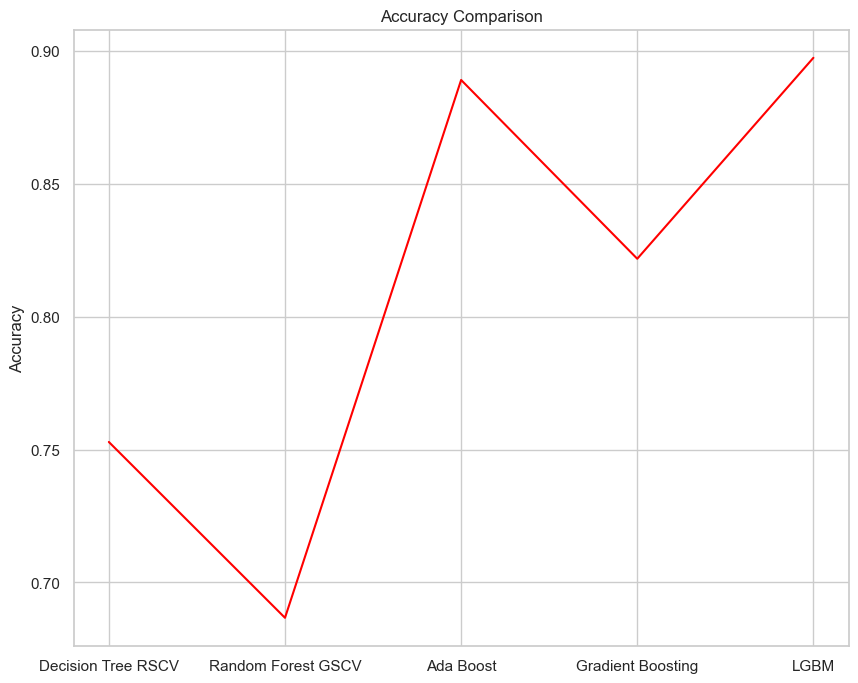

In [88]:
# Create A graph to compare between models based on Accuracy 
plt.figure(figsize=(10,8), dpi=100)
plt.plot(All_models.T.columns.T,All_models.T.iloc[5], color='red')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')

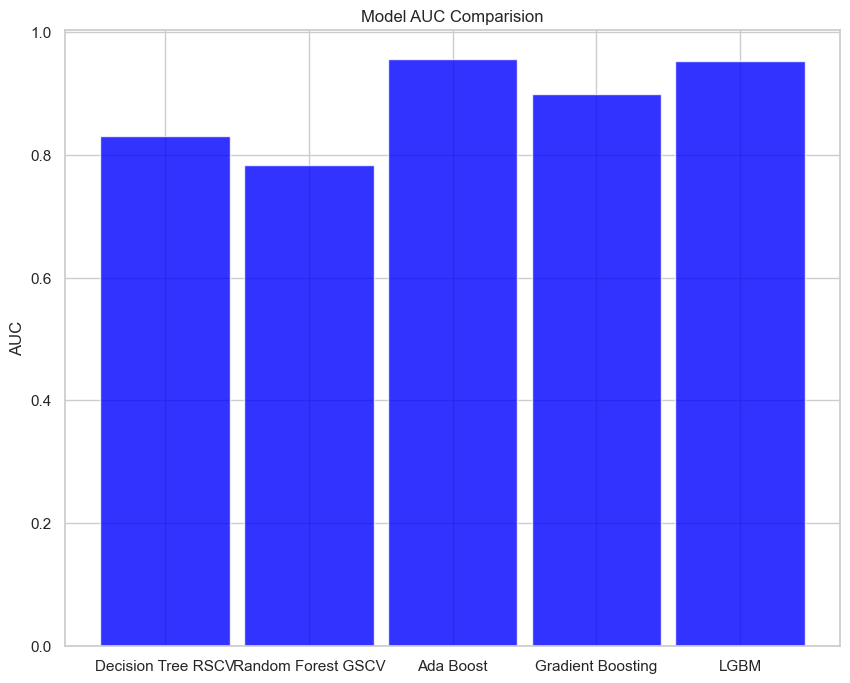

In [89]:
# Create a bar plot for AUC values
plt.figure(figsize=(10,8), dpi=100)
plt.bar(All_models.T.columns.T,All_models.T.iloc[6], width=0.9, alpha=0.8, color='blue')
plt.xticks(All_models.T.columns)
plt.ylabel('AUC')
plt.title('Model AUC Comparision')
# Display the plot
plt.show()

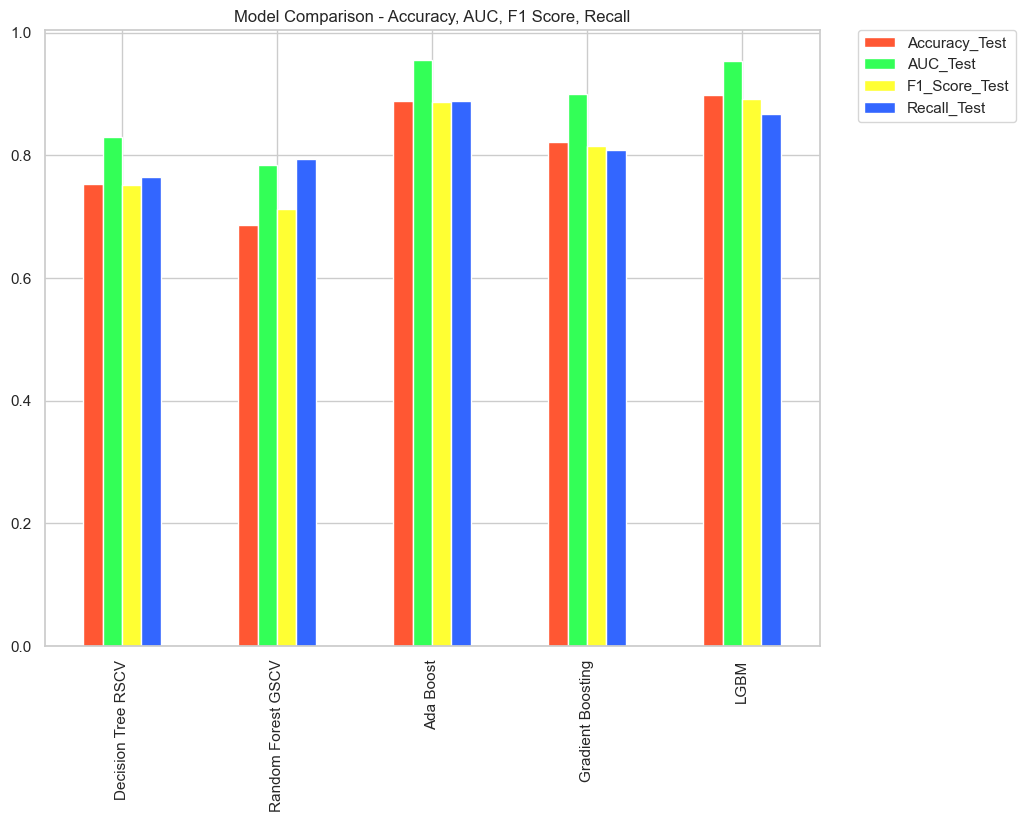

In [92]:
# Create an array of x-positions
xpos = np.array(list(range(len(All_models.T.columns))))
# Display the array
xpos

# create a new DataFrame db2 containing only these columns from the original All_models DataFrame
db2 = All_models[['Accuracy_Test','AUC_Test','F1_Score_Test','Recall_Test']]
# Display the dataframe
db2

# Plot the dataframe 
# Set the figure size
plt.rcParams['figure.figsize'] = (10, 8)
# Create a bar plot for the selected metrics in db2 DataFrame
db2.plot(kind='bar', color=['#FF5733', '#33FF57', '#FFFF33', '#3366FF'])
# Add a legend to the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# Set the title of the plot
plt.title("Model Comparison - Accuracy, AUC, F1 Score, Recall")
# Show the plot
plt.show()
